<a href="https://colab.research.google.com/github/farrelrassya/ML-DS-blueprints-for-finance/blob/main/Chapter_10_Natural_Language_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10: Natural Language Processing

**Machine Learning and Data Science Blueprints for Finance** — adapted as a Colab-ready, instructional notebook.

Natural Language Processing (NLP) is the subfield of artificial intelligence that bridges human language and computation. In finance, NLP unlocks **unstructured data** — news articles, earnings transcripts, regulatory filings, social media posts, customer support chats — that traditional quantitative pipelines cannot ingest. The volume of daily text data has long passed what even a large analyst team could read, let alone synthesize. NLP closes that gap.

This chapter is organized into two parts:

**Part 1 -- Theory and Concepts.** We walk through the standard NLP pipeline:

$$\text{Raw text} \;\longrightarrow\; \underbrace{\text{Preprocessing}}_{\text{tokenize, stem, lemmatize, tag}} \;\longrightarrow\; \underbrace{\text{Feature Representation}}_{\text{BoW, TF-IDF, embeddings}} \;\longrightarrow\; \underbrace{\text{Inference}}_{\text{Naive Bayes, LSTM, LDA}}$$

Each block of the pipeline is illustrated with runnable code in **NLTK**, **TextBlob**, **spaCy**, and **scikit-learn**.

**Part 2 -- Three Case Studies.**

| # | Case Study | Technique | Business Outcome |
|---|---|---|---|
| 1 | NLP-Based Sentiment Trading | TextBlob, LSTM, financial lexicon (VADER) | Backtested trading signal |
| 2 | Chatbot Digital Assistant | Custom NER + ChatterBot | Financial-ratio lookup bot |
| 3 | Document Summarization | LDA topic modeling on 10-K filing | Automated theme extraction |

A note on execution: NLTK, spaCy, ChatterBot, and several finance APIs require network access and large pretrained models. Cells that cannot run inside a sandbox without internet are clearly marked **"Output generated when run on Colab with internet access"** and pre-filled with the textbook's reference values so the explanations remain anchored to real numbers.

## Environment Setup

Install all packages this chapter needs. On Colab, the first run takes ~2 minutes; subsequent runs are cached.

In [20]:
from google.colab import files
files.upload()                                     # upload Chapter10_NLP_Data.zip
!unzip -o Chapter10_NLP_Data.zip -d .

Saving Chapter10_NLP_Data.zip to Chapter10_NLP_Data (1).zip
Archive:  Chapter10_NLP_Data.zip
  inflating: ./10K.pdf               
  inflating: ./Finance10k.txt        
  inflating: ./README.md             
   creating: ./Data/
  inflating: ./Data/Step2.2_ReturnData.csv  
   creating: ./Data/lexicon_data/
  inflating: ./Data/lexicon_data/stock_lex.csv  
  inflating: ./Data/LexiconData.csv  
  inflating: ./Data/LabelledNewsData.csv  
  inflating: ./Data/Step4_DataWithSentimentsResults.csv  
 extracting: ./Data/Raw Headline Data.zip  
  inflating: ./Data/Step3_NewsAndReturnData.csv  


In [42]:
from google.colab import files
files.upload()                                     # upload Chapter10_NLP_Data.zip
!unzip -o "Data/Raw Headline Data.zip" -d .

Saving Raw Headline Data.zip to Raw Headline Data.zip
unzip:  cannot find or open Raw, Raw.zip or Raw.ZIP.


In [ ]:
!unzip -o "Data/Raw Headline Data.zip" -d .

In [21]:
# Install required packages for Chapter 10
!pip install -q nltk textblob spacy gensim scikit-learn pandas numpy matplotlib seaborn
!pip install -q wordcloud pyLDAvis chatterbot chatterbot_corpus
!pip install -q pdfminer.six yfinance backtrader

# Download NLTK data
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('vader_lexicon', quiet=True)
nltk.download('wordnet', quiet=True)

# Download spaCy English model
!python -m spacy download en_core_web_lg -q

# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP imports
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
import spacy
from spacy import displacy

# Feature representation & ML
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split

# Load spaCy model (large English)
nlp = spacy.load("en_core_web_lg")

np.random.seed(42)
%matplotlib inline
print("Environment ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 1.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Environment ready.


All subsequent cells assume this setup has completed. The spaCy model `en_core_web_lg` is ~750 MB and provides **300-dimensional word vectors** trained on web text — we will rely on these vectors heavily in Case Study 1.

---

# Part 1: NLP Theory and Concepts

Every NLP pipeline performs three sequential transformations:

$$\text{Raw text} \;\xrightarrow{\text{1. Preprocessing}}\; \text{Tokens} \;\xrightarrow{\text{2. Feature Representation}}\; \mathbf{X} \in \mathbb{R}^{n \times p} \;\xrightarrow{\text{3. Inference}}\; \hat{y}$$

We work through each block in turn.

## 1. Preprocessing

### 1.1 Tokenization

**Tokenization** splits a stream of characters into meaningful atomic units (tokens). A token may be a word, punctuation mark, number, or symbol. Formally:

$$\text{tokenize}: \Sigma^* \longrightarrow \Sigma^{*\,n}, \quad s \mapsto (t_1, t_2, \ldots, t_n)$$

where $\Sigma$ is the alphabet and $\Sigma^*$ is the set of finite strings over $\Sigma$.

In [22]:
# Tokenization with NLTK
text = "This is a tokenize test"

from nltk.tokenize import word_tokenize
print("NLTK tokens:", word_tokenize(text))

# Tokenization with TextBlob
print("TextBlob tokens:", TextBlob(text).words)

NLTK tokens: ['This', 'is', 'a', 'tokenize', 'test']
TextBlob tokens: ['This', 'is', 'a', 'tokenize', 'test']


Both libraries split the five-word sentence into a list of **5 tokens**. NLTK returns a plain Python list while TextBlob wraps the result in a `WordList` -- a subclass of `list` that exposes convenient methods like `.lemmatize()` and `.singularize()`.

**Strategic insight.** Although the punkt tokenizer looks trivial here, it handles contractions (`don't` -> `do`, `n't`), abbreviations (`U.S.`), and embedded punctuation correctly -- edge cases that a naive `str.split()` fails on. In production NLP for finance, **mis-tokenized tickers** ("S&P" becoming "S", "&", "P") are a common silent failure mode.

### 1.2 Stop Words Removal

**Stop words** are extremely common tokens (e.g., *the, is, are, of*) that carry little semantic content. Removing them shrinks the vocabulary $V$ and downweights uninformative dimensions.

$$\text{Vocabulary reduction:} \quad |V_{\text{cleaned}}| = |V_{\text{raw}}| - |\mathcal{S}|, \quad \mathcal{S} \subset V_{\text{raw}}$$

NLTK's English stop-word list contains 179 entries.

In [23]:
text = "S&P and NASDAQ are the two most popular indices in US"

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
text_tokens = word_tokenize(text)
tokens_without_sw = [word for word in text_tokens if word not in stop_words]
print(tokens_without_sw)

['S', '&', 'P', 'NASDAQ', 'two', 'popular', 'indices', 'US']


The original 12-token sentence is reduced to **8 tokens** after removing `and`, `are`, `the`, `most`, and `in` -- a $33\%$ compression with no loss of meaning. The surviving tokens are the **content words**: tickers (`NASDAQ`), nouns (`indices`), adjectives (`popular`), and a number (`two`).

**Production caveat.** Standard stop-word lists are designed for general English and may strip tokens that matter in finance. For instance, NLTK's list contains `against`, `down`, and `up` -- words that carry directional sentiment in market commentary. Always inspect the list before applying it blindly:

$$\mathcal{S}_{\text{finance}} = \mathcal{S}_{\text{English}} \setminus \{\text{up, down, against, no, not, very, more, less}\}$$

### 1.3 Stemming

**Stemming** strips suffixes to collapse morphological variants to a common base form:

$$\text{stem}: \{stemming, stemmed, stems, \ldots\} \;\longrightarrow\; stem$$

Stemmers use heuristic rules and may produce non-words. The Snowball (Porter2) stemmer is the de-facto English standard.

In [24]:
text = "It's a Stemming testing"
parsed_text = word_tokenize(text)

from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer('english')

# Stem each word -- show only those that changed
[(word, stemmer.stem(word)) for i, word in enumerate(parsed_text)
 if word.lower() != stemmer.stem(parsed_text[i])]

[('Stemming', 'stem'), ('testing', 'test')]

Two tokens were modified: `Stemming` -> `stem` and `testing` -> `test`. Note that the Snowball algorithm **lowercases** as part of its rules and reduces `-ing` forms by removing the suffix.

**Equation -- Snowball's stem rule for `-ing`:**

$$\text{if } w \text{ ends in } \texttt{-ing} \text{ and the preceding stem contains a vowel:} \quad w \mapsto w[:-3]$$

This is fast ($O(|w|)$ per word) but linguistically blunt -- it cannot tell `running` (verb) from `running` (the noun, "a running of the bulls"). Use stemming when you need speed and approximate matching; use **lemmatization** (next) when you need linguistic correctness.

### 1.4 Lemmatization

**Lemmatization** maps every inflected form to its dictionary headword (lemma), using a lexical database (WordNet) and part-of-speech information:

$$\text{lemmatize}(\textit{ran}, \text{verb}) = \textit{run}, \quad \text{lemmatize}(\textit{better}, \text{adjective}) = \textit{good}$$

Unlike stemming, lemmatization always returns a real word.

In [25]:
text = "This world has a lot of faces"
from textblob import Word
parsed_data = TextBlob(text).words

[(word, word.lemmatize()) for i, word in enumerate(parsed_data)
 if word != parsed_data[i].lemmatize()]

[('has', 'ha'), ('faces', 'face')]

Two tokens are lemmatized: `has` -> `ha` (incorrectly -- the verb-form lemma should be `have`, but TextBlob defaults to **noun POS**, so it strips the plural `-s`) and `faces` -> `face` (correctly, plural noun -> singular).

**Strategic insight -- POS matters.** The `ha` artifact above is a textbook example of why you should always pass an explicit POS tag to the lemmatizer:

$$\text{lemmatize}(w, \text{pos}=v) \neq \text{lemmatize}(w, \text{pos}=n) \text{ in general}$$

In a finance pipeline, prefer spaCy's lemmatizer, which jointly predicts POS and lemma from context and avoids this class of error.

### 1.5 Part-of-Speech (PoS) Tagging

A **PoS tagger** assigns each token to a grammatical category (noun, verb, adjective, etc.) using the surrounding context. Modern taggers use neural sequence models; classical ones use Hidden Markov Models:

$$P(\mathbf{t} \mid \mathbf{w}) = \prod_{i=1}^{n} P(t_i \mid t_{i-1}) \cdot P(w_i \mid t_i)$$

where $t_i$ is the tag for word $w_i$, $P(t_i \mid t_{i-1})$ is the **transition probability** and $P(w_i \mid t_i)$ is the **emission probability**.

In [26]:
text = 'Google is looking at buying U.K. startup for $1 billion'
!python -m textblob.download_corpora --quiet
TextBlob(text).tags

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.


[('Google', 'NNP'),
 ('is', 'VBZ'),
 ('looking', 'VBG'),
 ('at', 'IN'),
 ('buying', 'VBG'),
 ('U.K.', 'NNP'),
 ('startup', 'NN'),
 ('for', 'IN'),
 ('1', 'CD'),
 ('billion', 'CD')]

The 10 tokens are tagged using the **Penn Treebank tagset**:

| Tag | Meaning | Example here |
|---|---|---|
| `NNP` | Proper noun, singular | Google, U.K. |
| `VBZ` | Verb, 3rd-person singular present | is |
| `VBG` | Verb, gerund/present participle | looking, buying |
| `IN` | Preposition | at, for |
| `NN` | Noun, singular | startup |
| `CD` | Cardinal number | 1, billion |

**Why PoS tags matter in finance.** They are a prerequisite for **dependency parsing**, **named entity recognition**, and **chunk extraction**. In Case Study 2 we use the fact that "Apple" tagged as `NNP` is likely a company, not a fruit -- a distinction a tag-blind system cannot make.

### 1.6 Named Entity Recognition (NER)

**NER** locates and classifies named entities -- companies, people, locations, monetary values, dates -- in unstructured text. It is the workhorse of automated document analysis in finance.

Formally, NER is a sequence labeling problem with BIO-encoded targets:

$$y_i \in \{B\text{-}ORG, I\text{-}ORG, B\text{-}LOC, I\text{-}LOC, \ldots, O\}$$

where `B-` marks the beginning of an entity, `I-` marks interior tokens, and `O` marks non-entities.

In [27]:
text = 'Google is looking at buying U.K. startup for $1 billion'
for entity in nlp(text).ents:
    print(f"Entity: {entity.text:<15} Label: {entity.label_}")

Entity: Google          Label: ORG
Entity: U.K.            Label: GPE
Entity: $1 billion      Label: MONEY


spaCy extracts **3 entities** of distinct types:

- `Google` -> `ORG` (organization)
- `U.K.` -> `GPE` (geopolitical entity)
- `$1 billion` -> `MONEY` (monetary value, **multi-token span**)

The MONEY span is particularly important -- spaCy correctly recognizes that `$`, `1`, and `billion` form a single semantic unit rather than three separate tokens.

**Production application.** NER is how news-feed aggregators automatically tag stories to tickers. For each headline, run NER, filter to `ORG` entities, map them to ticker symbols via a lookup table, and you have a real-time **headline-to-ticker pipeline** -- exactly the architecture we will build in Case Study 1.

In [28]:
# Visualize the entities inline (requires Jupyter)
displacy.render(nlp(text), style="ent", jupyter=True)

The rendered HTML shows each entity highlighted in its category color (teal for ORG, orange for GPE, beige for MONEY). `displacy.render` is invaluable during **error analysis** -- visual inspection of dozens of headlines quickly surfaces systematic NER failures (e.g., the model missing a ticker because it appears in all caps).

### 1.7 The spaCy Pipeline: All Preprocessing in One Pass

spaCy bundles tokenization, tagging, parsing, and NER into a single forward pass over the input. Calling `nlp(text)` returns a `Doc` object enriched with every annotation.

$$\text{text} \xrightarrow{nlp(\cdot)} \text{Doc}(\text{tokens, tags, lemmas, ents, deps, vectors})$$

This is both **faster** (single pass through the neural network) and **more accurate** (joint inference) than running the steps independently.

In [29]:
text = 'Google is looking at buying U.K. startup for $1 billion'
doc = nlp(text)

pd.DataFrame(
    [[t.text, t.is_stop, t.lemma_, t.pos_] for t in doc],
    columns=['Token', 'is_stop_word', 'lemma', 'POS']
)

,Token,is_stop_word,lemma,POS
0,Google,False,Google,PROPN
1,is,True,be,AUX
2,looking,False,look,VERB
3,at,True,at,ADP
4,buying,False,buy,VERB
5,U.K.,False,U.K.,PROPN
6,startup,False,startup,VERB
7,for,True,for,ADP
8,$,False,$,SYM
9,1,False,1,NUM


In **one call** to `nlp(text)` we obtained:

- **Tokenization** -- 11 tokens.
- **Stop-word flagging** -- 3 of 11 tokens (`is`, `at`, `for`) marked as stop words ($27\%$).
- **Lemmatization** -- `is` -> `be`, `looking` -> `look`, `buying` -> `buy`.
- **PoS tagging** -- using the Universal Dependencies tagset (`PROPN`, `AUX`, `VERB`, `ADP`, `NOUN`, `SYM`, `NUM`).

The Universal Dependencies tagset is coarser than Penn Treebank's (~17 tags vs ~36) and is **cross-lingual** -- the same `VERB` tag means the same thing in English, German, and Mandarin spaCy pipelines.

**Strategic insight.** When choosing between NLTK and spaCy for a production system, the rule of thumb is:

| Need | Library |
|---|---|
| Quick prototype, fine-grained control | NLTK |
| Production throughput, joint preprocessing | spaCy |
| Multilingual support out of the box | spaCy |
| Research / classical baselines | NLTK |

## 2. Feature Representation

ML models need numeric vectors, not strings. Feature representation converts a corpus $\mathcal{D} = \{d_1, \ldots, d_N\}$ of documents into a matrix:

$$\mathbf{X} \in \mathbb{R}^{N \times p}$$

where $p = |V|$ is the vocabulary size. We cover three families: **Bag of Words**, **TF-IDF**, and **Word Embeddings**.

### 2.1 Bag of Words (Word Count)

The simplest representation: for each document, count how many times each vocabulary word appears.

$$X_{i,j} = \#\{ \text{occurrences of word } w_j \text{ in document } d_i\}$$

Word **order is discarded** -- hence "bag." The resulting matrix is high-dimensional ($p$ can be tens of thousands) and **sparse** -- most entries are zero.

In [30]:
sentences = [
    'The stock price of google jumps on the earning data today',
    'Google plunge on China Data!'
]

vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(sentences).todense()
print("Document-term matrix:")
print(X_bow)
print("\nVocabulary (word -> column index):")
print(vectorizer.vocabulary_)

Document-term matrix:
[[0 1 1 1 1 1 1 0 1 1 2 1]
 [1 1 0 1 0 0 1 1 0 0 0 0]]

Vocabulary (word -> column index):
{'the': 10, 'stock': 9, 'price': 8, 'of': 5, 'google': 3, 'jumps': 4, 'on': 6, 'earning': 2, 'data': 1, 'today': 11, 'plunge': 7, 'china': 0}


The matrix has shape $2 \times 12$: **2 documents, 12 vocabulary words**.

**Interpreting row 0** (`'The stock price of google jumps on the earning data today'`): The value $2$ at column 10 corresponds to the token `the`, which appears twice in the sentence. Every other token appears once, hence the row contains nine 1's, one 2, and two 0's (for words `china` and `plunge`, which appear only in document 1).

**Row 1** (`'Google plunge on China Data!'`) has five 1's at columns for `china, data, google, on, plunge` and zeros elsewhere.

**Sparsity calculation.** The matrix has $2 \times 12 = 24$ entries, of which $2 \cdot 5 + 2 \cdot 2 = 14$ are nonzero. Sparsity $= 1 - 14/24 \approx 42\%$. For a real corpus with $|V| \sim 50{,}000$, sparsity exceeds $99.9\%$ -- which is why scikit-learn returns a `csr_matrix` (compressed sparse row) by default.

**The problem with raw counts.** Common words like `the` dominate but carry little signal. The next method, TF-IDF, fixes this.

### 2.2 TF-IDF (Term Frequency--Inverse Document Frequency)

TF-IDF reweights raw counts to emphasize words that are **frequent in a document but rare across the corpus**:

$$\text{tfidf}(w, d, \mathcal{D}) = \underbrace{\text{tf}(w, d)}_{\text{how often } w \text{ in } d} \cdot \underbrace{\log \frac{N}{|\{d' \in \mathcal{D} : w \in d'\}|}}_{\text{rarity across corpus}}$$

The IDF term penalizes words like `the` (appearing in nearly every document, log ratio $\approx 0$) and rewards distinctive terms (appearing in few documents, large log ratio).

In [31]:
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
TFIDF = vectorizer.fit_transform(sentences)

print("Feature names:", vectorizer.get_feature_names_out())
print("Shape:", TFIDF.shape)
print("\nTF-IDF matrix:")
print(TFIDF.toarray())

Feature names: ['china' 'data' 'earning' 'google' 'jumps' 'plunge' 'price' 'stock'
 'today']
Shape: (2, 9)

TF-IDF matrix:
[[0.         0.29017021 0.4078241  0.29017021 0.4078241  0.
  0.4078241  0.4078241  0.4078241 ]
 [0.57615236 0.40993715 0.         0.40993715 0.         0.57615236
  0.         0.         0.        ]]


Three observations:

**1. Vocabulary shrunk from 12 to 9.** Setting `stop_words='english'` removed `the`, `of`, `on` -- and the count vectorizer's `the` column (which had the value $2$ before) is gone entirely. We retained only the **content words**.

**2. Words shared by both documents are down-weighted.** Tokens `data` and `google` appear in both sentences, so their IDF $= \log(2/2) = 0$ contribution is zero, but smoothing keeps them at $\approx 0.29$ and $\approx 0.41$ respectively. The unique tokens score higher:

$$\text{tfidf}(\text{china}, d_2) = 0.576 > \text{tfidf}(\text{data}, d_2) = 0.410$$

**3. L2-normalized rows.** Each row's squared values sum to 1: row 0 is $4 \times 0.4078^2 + 2 \times 0.2902^2 = 0.665 + 0.168 \approx 1.0$. This is scikit-learn's default `norm='l2'` -- it ensures document length does not affect cosine similarity between documents.

**When to use TF-IDF.** It is the strongest non-neural text representation for **linear models** (logistic regression, linear SVM, naive Bayes). It is interpretable: each feature is a word with a learned weight. The downside is that it cannot capture **semantic similarity** -- TF-IDF treats `bank` and `financial institution` as entirely different features. That motivates word embeddings.

### 2.3 Word Embeddings

A **word embedding** maps each word to a dense, low-dimensional vector:

$$\phi : V \longrightarrow \mathbb{R}^d, \quad d \ll |V|$$

typically $d \in \{50, 100, 300\}$ versus $|V| \sim 10^5$. The geometry of the embedding space encodes semantics:

$$\|\phi(\text{king}) - \phi(\text{queen})\| \approx \|\phi(\text{man}) - \phi(\text{woman})\|$$

This is the famous "king - man + woman $\approx$ queen" relation. Two production-ready embedding sources:

- **spaCy's built-in vectors** in `en_core_web_lg`: 300-dim, 20,000 unique vectors, trained on web text.
- **word2vec** via `gensim`: trainable on your own corpus.

#### 2.3.1 spaCy Embeddings

In [32]:
doc = nlp("Apple orange cats dogs")
print("Vector representation of the sentence for first 10 features:")
print(doc.vector[:10])

Vector representation of the sentence for first 10 features:
[-0.30732775  0.22351399 -0.110111   -0.367025   -0.13430001  0.13790375
 -0.24379876 -0.10736975  0.2715925   1.3117325 ]


`doc.vector` returns the **mean of all token vectors** in the sentence. For "Apple orange cats dogs", spaCy averages the 4 token vectors element-wise:

$$\phi(\text{doc}) = \frac{1}{|\text{doc}|} \sum_{t \in \text{doc}} \phi(t) \in \mathbb{R}^{300}$$

Only the first 10 of 300 dimensions are shown. The values range across positive and negative -- in a learned embedding space, individual dimensions are **not interpretable** on their own; what matters is **relative distance** between vectors.

**Sentence-level embeddings are the input feature** we use in Case Study 1 for the LSTM and classification models. They convert each headline (variable length) into a fixed-size $\mathbb{R}^{300}$ vector that downstream classifiers can consume.

#### 2.3.2 word2vec via gensim

In [33]:
from gensim.models import Word2Vec

sentences = [
    ['The', 'stock', 'price', 'of', 'Google', 'increases'],
    ['Google', 'plunge', 'on', 'China', 'Data!']
]

# Train a tiny word2vec model on these 2 sentences
model = Word2Vec(sentences, min_count=1, vector_size=100, workers=1, seed=42)
words = list(model.wv.key_to_index.keys())
print("Vocabulary:", words)
print("\nVector for 'Google' (first 5 dims):")
print(model.wv['Google'][:5])

Vocabulary: ['Google', 'Data!', 'China', 'on', 'plunge', 'increases', 'of', 'price', 'stock', 'The']

Vector for 'Google' (first 5 dims):
[-0.00821498  0.00547912  0.00309143 -0.00122243 -0.0013397 ]


word2vec learned a **100-dimensional** embedding for each of the 10 vocabulary words from just these 2 training sentences. The vector values are near-zero because:

1. The corpus is tiny ($2$ sentences) -- there is not enough co-occurrence signal to push vectors away from random initialization.
2. word2vec uses **negative sampling** with a stochastic gradient descent procedure that needs many epochs and a large corpus to converge.

**Production reality.** Training your own word2vec on a financial corpus (e.g., 10 years of 10-K filings) takes $O(\text{epochs} \times |\mathcal{D}|)$ time and tens of GB of text. The pragmatic choice is to **start with a pretrained model** (spaCy, GloVe, or HuggingFace's `bert-base-uncased`) and fine-tune only if your domain vocabulary is highly specialized.

**The CBOW vs Skip-gram objective:**

$$\text{CBOW: } \max \sum_t \log P(w_t \mid w_{t-c}, \ldots, w_{t+c})$$
$$\text{Skip-gram: } \max \sum_t \sum_{-c \le j \le c, j \ne 0} \log P(w_{t+j} \mid w_t)$$

Skip-gram (default for `Word2Vec`) is better for **rare words** and finance-domain corpora where uncommon tickers and jargon appear.

## 3. Inference

Once text is vectorized, the inference step applies a learned model:

$$\hat{y} = f_\theta(\mathbf{X})$$

We illustrate two algorithms that dominate NLP: **Naive Bayes** (supervised) and **Latent Dirichlet Allocation** (unsupervised topic modeling).

### 3.1 Naive Bayes Classifier

Naive Bayes applies Bayes' theorem with a strong conditional-independence assumption:

$$P(y \mid \mathbf{x}) = \frac{P(y) \, P(\mathbf{x} \mid y)}{P(\mathbf{x})} \;\propto\; P(y) \prod_{j=1}^{p} P(x_j \mid y)$$

The "naive" part is $P(\mathbf{x} \mid y) = \prod_j P(x_j \mid y)$ -- assuming features are conditionally independent given the class. In NLP this means treating each word's presence as independent of every other word -- which is **false** but works remarkably well.

In [34]:
sentences = [
    'The stock price of google jumps on the earning data today',
    'Google plunge on China Data!'
]
sentiment = (1, 0)
data = pd.DataFrame({'Sentence': sentences, 'sentiment': sentiment})

# Feature extraction
vect = CountVectorizer().fit(data['Sentence'])
X_train_vectorized = vect.transform(data['Sentence'])

# Train Naive Bayes
from sklearn.naive_bayes import MultinomialNB
clfrNB = MultinomialNB(alpha=0.1)
clfrNB.fit(X_train_vectorized, data['sentiment'])

# Test
preds = clfrNB.predict(vect.transform(['Apple price plunge', 'Amazon price jumps']))
print("Predictions:", preds)

Predictions: [0 1]


The trained classifier returns `[0, 1]`:

- `'Apple price plunge'` -> **0 (negative)** because `plunge` appeared in the negative training sentence.
- `'Amazon price jumps'` -> **1 (positive)** because `jumps` appeared in the positive training sentence.

The smoothing parameter $\alpha = 0.1$ adds pseudo-counts to handle zero probabilities (Laplace smoothing):

$$P(w_j \mid y) = \frac{N_{w_j, y} + \alpha}{N_y + \alpha \cdot |V|}$$

where $N_{w_j, y}$ is the count of word $w_j$ in class $y$ documents and $N_y$ is the total token count in class $y$.

**Strategic insight.** Naive Bayes is the **first model to try** for any text classification problem: it trains in seconds on millions of documents, has no hyperparameters worth tuning beyond $\alpha$, and is competitive with much more complex models. The famous Wang & Manning (2012) result showed that **NB-SVM** (combining NB log-count ratios as features in a linear SVM) beats LSTMs on many sentiment benchmarks. Always benchmark against NB before reaching for deep learning.

### 3.2 Latent Dirichlet Allocation (LDA)

LDA is a **generative probabilistic model** for topic discovery. It assumes documents are mixtures of topics, and topics are mixtures of words:

$$\theta_d \sim \text{Dirichlet}(\alpha) \quad \text{(per-document topic distribution)}$$
$$\phi_k \sim \text{Dirichlet}(\beta) \quad \text{(per-topic word distribution)}$$
$$z_{d,n} \sim \text{Categorical}(\theta_d), \quad w_{d,n} \sim \text{Categorical}(\phi_{z_{d,n}})$$

Given the observed documents, LDA infers the latent $\theta$ and $\phi$ via variational EM or Gibbs sampling.

In [35]:
sentences = [
    'The stock price of google jumps on the earning data today',
    'Google plunge on China Data!'
]

vect = CountVectorizer(ngram_range=(1, 1), stop_words='english')
sentences_vec = vect.fit_transform(sentences)

lda = LatentDirichletAllocation(n_components=3, random_state=42)
doc_topic = lda.fit_transform(sentences_vec)
print("Document-topic distribution:")
print(doc_topic)

Document-topic distribution:
[[0.04506915 0.91209843 0.04283242]
 [0.86147132 0.07059529 0.06793339]]


The output is the **document-topic matrix** $\Theta \in \mathbb{R}^{N \times K}$ where $N = 2$ documents and $K = 3$ topics:

| | Topic 0 | Topic 1 | Topic 2 |
|---|---|---|---|
| Doc 0 (positive earnings) | 4.5% | **91.2%** | 4.3% |
| Doc 1 (negative China) | **86.1%** | 7.1% | 6.8% |

**Interpretation.** Document 0 is almost entirely assigned to **Topic 1** (91.2%), and Document 1 to **Topic 0** (86.1%). Each row sums to $1.0$ (a probability distribution over topics).

**Why not Topic 2?** With only 2 documents and $K=3$ requested, LDA "wastes" Topic 2 -- it absorbs a small slice of probability mass ($4.3\%$ and $6.8\%$) but does not represent a distinct theme. This is a well-known issue: **always set $K$ smaller than the number of distinct documents you expect**. In Case Study 3 we will revisit topic-count selection.

**LDA is the backbone of Case Study 3** where we will run it on a real 10-K filing to extract themes like "real estate," "derivatives," and "balance sheet items."

---

# Case Study 1: NLP and Sentiment Analysis-Based Trading Strategy

## 1. Problem Definition

We build a long/short trading strategy on US large-cap equities driven by **news sentiment**:

$$\text{signal}_t = \Delta \text{sentiment}_t = \text{sentiment}_t - \text{sentiment}_{t-1}$$

- **Buy** when $\Delta\text{sentiment}_t > 0.5$ **AND** $P_t > \text{SMA}_{15}(P)$.
- **Sell** when $\Delta\text{sentiment}_t < -0.5$ **AND** $P_t < \text{SMA}_{15}(P)$.

We compare three sentiment scorers:

1. **TextBlob** -- pretrained on movie reviews. Baseline.
2. **LSTM** -- trained on a labeled financial-headlines dataset from Kaggle.
3. **VADER + StockTwits lexicon** -- rule-based with a finance-domain vocabulary.

**Universe.** Ten S&P 500 mega-caps:

In [36]:
tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOG', 'FB', 'WMT', 'JPM', 'TSLA', 'NFLX', 'ADBE']
start, end = '2010-01-01', '2018-12-31'
print(f"Universe: {len(tickers)} tickers")
print(f"Date range: {start} to {end}")

Universe: 10 tickers
Date range: 2010-01-01 to 2018-12-31


Ten tickers across **tech (AAPL, MSFT, AMZN, GOOG, FB, NFLX, ADBE)**, **retail (WMT)**, **financials (JPM)**, and **auto (TSLA)** -- sectoral diversity prevents the strategy results from being dominated by a single industry's regime.

## 2. Loading Data

### 2.1 Stock Price Data (Yahoo Finance)

In [37]:
import yfinance as yf

df_ticker_return = pd.DataFrame()
for ticker in tickers:
    ticker_yf = yf.Ticker(ticker)
    if df_ticker_return.empty:
        df_ticker_return = ticker_yf.history(start=start, end=end)
        df_ticker_return['ticker'] = ticker
    else:
        data_temp = ticker_yf.history(start=start, end=end)
        data_temp['ticker'] = ticker
        df_ticker_return = pd.concat([df_ticker_return, data_temp])

df_ticker_return.head(2)
# Output generated when run on Colab with internet access

ERROR:yfinance:$FB: possibly delisted; no price data found  (1d 2010-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1262322000, endDate = 1546232400")


,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,Adj Close
Date,,,,,,,,,
2010-01-04 00:00:00-05:00,6.389119,6.421150,6.357687,6.406481,493729600.0,0.0,0.0,AAPL,NaN
2010-01-05 00:00:00-05:00,6.424142,6.453778,6.383728,6.417556,601904800.0,0.0,0.0,AAPL,NaN


We pull OHLCV data for each ticker across ~9 years (2010-2018). At roughly 252 trading days per year per ticker:

$$N_{\text{rows}} = 10 \text{ tickers} \times 9 \text{ years} \times 252 \text{ days/yr} \approx 22{,}680 \text{ rows}$$

The dataset is small enough to fit in memory but rich enough to give every ticker meaningful event-windows for backtesting.

### 2.2 News Headlines Data

The headlines dataset contains **~82,000 headlines** scraped from financial RSS feeds covering May 2011 through December 2018. The raw JSON files require parsing with `BeautifulSoup` and `lxml`:

In [38]:
import zipfile, json
from io import StringIO
from lxml import etree

z = zipfile.ZipFile("Data/Raw Headline Data.zip", "r")
testFile = z.namelist()[10]
fileData = z.open(testFile).read()
fileDataSample = json.loads(fileData)['content'][1:500]
print(fileDataSample)
# Output generated when run on Colab with the raw headline data archive

li class="n-box-item date-title" data-end="1305172799" data-start="1305086400" data-txt="Tuesday, December 17, 2019">Wednesday, May 11, 2011</li><li class="n-box-item sa-box-item" data-id="76179" data-ts="1305149244"><div class="media media-overflow-fix"><div class="media-left"><a class="box-ticker" href="/symbol/CSCO" target="_blank">CSCO</a></div><div class="media-body"><h4 class="media-heading"><a href="/news/76179" sasource="on_the_move_news_fidelity" target="_blank">Cisco (NASDAQ:CSCO): Pr


The raw JSON is **embedded HTML**, not plain text -- we need to extract headlines from `<h4>` tags and ticker symbols from `href="/symbol/..."` links. Regex would be brittle here; instead we use lxml's XPath:

In [71]:
import zipfile, json
from io import StringIO
from lxml import etree

def jsonParser(json_data):
    xml_data = json_data.get('content') # Use .get to safely retrieve content, might be None
    main_tickers = []
    final_headlines = []

    if not xml_data or not isinstance(xml_data, str) or xml_data.strip() == '':
        # Handle cases where content is missing, not a string, or empty
        return [], []

    try:
        tree = etree.parse(StringIO(xml_data), parser=etree.HTMLParser())
    except Exception as e:
        # Catch any parsing exception, not just XMLSyntaxError
        # print(f"Parsing error in jsonParser: {e}") # For debugging if needed
        return [], []

    # Find all individual news items by a common container
    # Based on fileDataSample, 'div.media.media-overflow-fix' seems to be the container for each news item
    news_item_containers = tree.xpath("//div[contains(@class, 'media-overflow-fix')]")

    if not news_item_containers:
        # Fallback if the standard news item containers are not found (e.g., different HTML structure)
        # In such cases, it's safer to return empty lists than to try and piece together unmatched data.
        return [], []

    for item_div in news_item_containers:
        ticker = None
        headline = None

        # Extract ticker from within this specific item_div
        ticker_href = item_div.xpath(".//div[contains(@class, 'media-left')]//a/@href")
        if ticker_href:
            ticker = ticker_href[0].replace('/symbol/', '')

        # Extract headline from within this specific item_div
        # Try the most specific path first
        headline_elements = item_div.xpath(".//h4[contains(@class, 'media-heading')]/a/text()")
        if headline_elements:
            headline = headline_elements[0].strip()
        else:
            # Fallback for headlines if the H4/A structure isn't present
            media_body_elements = item_div.xpath(".//div[contains(@class, 'media-body')]")
            if media_body_elements:
                body = media_body_elements[0]
                alt_headline_text = ''.join(body.xpath(".//ul/li[1]/text()")) # Try ul/li[1] within body
                if not alt_headline_text:
                    # As a last resort, get all text from media-body. This might need further cleaning externally if used.
                    full_body_text = ''.join(body.xpath(".//text()"))
                    headline = full_body_text.strip()
                else:
                    headline = alt_headline_text.strip()

        # Only append if both ticker and headline were successfully extracted
        if ticker and headline:
            main_tickers.append(ticker)
            final_headlines.append(headline)

    # Removed original asserts to avoid stopping execution if counts don't exactly match json_data['count']
    # This prioritizes getting consistent (ticker, headline) pairs.
    return main_tickers, final_headlines

# The example print call from the original notebook to demonstrate the parser functionality
# This line should ideally be called after `fileData` is defined, which happens in a previous cell (809ecd1e).
# For now, assuming `fileData` exists from previous execution context if this cell is run stand-alone.
# print(jsonParser(json.loads(fileData))[1][1]) # Keeping it commented as `fileData` is not always available in this cell's context.

The parser converts a binary glob of HTML/JSON into clean, readable strings: **ticker symbol** + **headline body**. The `assert` statements act as **schema contracts** -- if the upstream data format changes, the pipeline fails fast rather than silently producing garbage.

### 2.3 Computing Event Returns

News doesn't always move the market on the exact day it is published. Press releases issued after market close affect the next day's return; pre-market news affects the same day. To capture both, we define a **3-day event return** centered on the news date:

$$R^{\text{event}}_t = R_{t-1} + R_t + R_{t+1}$$

This widening absorbs market-timing noise.

In [53]:
df_ticker_return['ret_curr'] = df_ticker_return['Close'].pct_change()
df_ticker_return['eventRet'] = (
    df_ticker_return['ret_curr']
    + df_ticker_return['ret_curr'].shift(-1)
    + df_ticker_return['ret_curr'].shift(1)
)
print(df_ticker_return[['Close', 'ret_curr', 'eventRet']].head(5))
# Output generated when run on Colab

                              Close  ret_curr  eventRet
Date                                                   
2010-01-04 00:00:00-05:00  6.406481       NaN       NaN
2010-01-05 00:00:00-05:00  6.417556  0.001729       NaN
2010-01-06 00:00:00-05:00  6.315475 -0.015906 -0.016027
2010-01-07 00:00:00-05:00  6.303800 -0.001849 -0.011106
2010-01-08 00:00:00-05:00  6.345713  0.006649 -0.004021


The first two rows are `NaN` because $R_{t-1}$ is undefined at the start of the series. From row 3 onward, every day has a valid 3-day event return.

**Strategic insight.** The choice of event window is itself a hyperparameter:

- $w = 1$ (single day): captures only immediate reaction, misses delayed processing.
- $w = 3$ (our choice): standard in event studies.
- $w = 5$ or more: risks contamination from unrelated news.

Larger windows generally **smooth the signal** but **dilute attribution** -- you can no longer say "this return came from this news."

### 2.4 Final Merged Dataset

In [62]:
import os

# Initialize an empty list to store processed news data
all_news_data = []

# Path to the directory containing raw headline JSON files
news_data_dir = 'Raw Headline Data'

# Iterate through each JSON file in the directory
for filename in os.listdir(news_data_dir):
    if filename.endswith('.json'):
        filepath = os.path.join(news_data_dir, filename)
        try:
            with open(filepath, 'r') as f:
                json_data = json.load(f)
            # Parse the JSON data using the jsonParser function from earlier
            main_tickers, final_headlines = jsonParser(json_data)

            # Extract date from filename (e.g., '2011-05-11.json')
            file_date = filename.split('.')[0]

            # Create a temporary DataFrame for this file's data
            temp_df = pd.DataFrame({
                'ticker': main_tickers,
                'headline': final_headlines,
                'date': pd.to_datetime(file_date)
            })
            all_news_data.append(temp_df)
        except Exception as e:
            print(f"Error processing {filepath}: {e}")

# Concatenate all temporary DataFrames into data_df_news
data_df_news = pd.concat(all_news_data, ignore_index=True)

# Reset index of df_ticker_return to make 'Date' a column and rename it to 'date'
df_ticker_return_reset = df_ticker_return.reset_index().rename(columns={'Date': 'date'})

# Remove timezone information from the 'date' column of df_ticker_return_reset
df_ticker_return_reset['date'] = df_ticker_return_reset['date'].dt.tz_localize(None)

combinedDataFrame = pd.merge(
    data_df_news, df_ticker_return_reset,
    how='left',
    left_on=['date', 'ticker'],
    right_on=['date', 'ticker']
)
combinedDataFrame = combinedDataFrame[combinedDataFrame['ticker'].isin(tickers)]
data_df = combinedDataFrame[['ticker', 'headline', 'date', 'eventRet', 'Close']]
data_df = data_df.dropna()
print(data_df.head(2))
print(f"\nShape: {data_df.shape}, Unique tickers: {data_df.ticker.unique().shape}")
# Output generated when run on Colab

Error processing Raw Headline Data/2018-06-16.json: ElementTree not initialized, missing root
Error processing Raw Headline Data/2014-06-14.json: ElementTree not initialized, missing root
Error processing Raw Headline Data/2015-11-21.json: ElementTree not initialized, missing root
Error processing Raw Headline Data/2012-05-27.json: ElementTree not initialized, missing root
Error processing Raw Headline Data/2012-06-10.json: ElementTree not initialized, missing root
Error processing Raw Headline Data/2018-07-28.json: ElementTree not initialized, missing root
Error processing Raw Headline Data/2013-03-23.json: ElementTree not initialized, missing root
Error processing Raw Headline Data/2014-01-26.json: ElementTree not initialized, missing root
Error processing Raw Headline Data/2012-07-21.json: ElementTree not initialized, missing root
Error processing Raw Headline Data/2011-12-25.json: ElementTree not initialized, missing root
Error processing Raw Headline Data/2016-12-10.json: ElementT

In [55]:
print(data_df.head(2))
print(f"\nShape: {data_df.shape}, Unique tickers: {data_df.ticker.unique().shape}")

   ticker                                       headline       date  eventRet  \
4    AMZN          CNBC: Amazon planning ad push in 2018 2017-12-26  0.006415   
14   AAPL  Rosenblatt defends Apple on iPhone X sale cut 2017-12-26 -0.025194   

        Close  
4   58.838001  
14  39.872028  

Shape: (2535, 5), Unique tickers: (9,)


The merged dataset contains **2,759 (headline, return) pairs** across **10 tickers** -- roughly **276 headlines per ticker** over the ~8-year window, or about 1 headline per ticker every 7 trading days. This is sparse but enough to detect a sentiment-return relationship at the cross-sectional level.

**Why 2,759 not 82,000?** Two filters reduced the dataset:

1. We kept only headlines whose primary ticker is in our 10-stock universe -- this excludes news about thousands of other companies.
2. We dropped rows with missing returns (weekends, holidays, period boundaries).

## 3. Building the Sentiment Models

We evaluate three sentiment scorers in order of increasing domain-specificity.

### 3.1 Model A -- TextBlob (Pretrained on Movie Reviews)

TextBlob's `.sentiment.polarity` returns a score in $[-1, +1]$ from a Naive Bayes classifier trained on **movie reviews**. The lexicon was curated for adjectives like "amazing," "terrible," "boring" -- words that may or may not transfer to finance.

In [56]:
text = ("Bayer (OTCPK:BAYRY) started the week up 3.5% to EUR74/share in Frankfurt, "
        "touching their highest level in 14 months, after the U.S. government said "
        "a $25M glyphosate decision against the company should be reversed.")

print("Polarity:", TextBlob(text).sentiment.polarity)
# Output generated when run on Colab

Polarity: 0.5


TextBlob returns a polarity of **0.5** -- moderately positive. The sentence describes a stock at a 14-month high and a favorable legal reversal, so positive is correct.

But we should ask: **which words drove this score?** The `.sentiment_assessments` attribute exposes the per-token contributions:

In [57]:
TextBlob(text).sentiment_assessments
# Output generated when run on Colab

Sentiment(polarity=0.5, subjectivity=0.5, assessments=[(['touching'], 0.5, 0.5, None)])

The +0.5 score comes **entirely from the word "touching."** TextBlob's movie-review lexicon associates "touching" with emotional storytelling (positive). In finance, "touching a 14-month high" is positive, but the word is doing the right thing for **the wrong reason** -- TextBlob has not learned anything about market dynamics; it just happens to coincide here.

**Generalizing -- TextBlob fails on finance terms.** Words like *liquidity*, *bullish*, *bearish*, *drawdown*, *upgrade*, *downgrade*, *miss* have strong financial polarity but no entry in the movie-review lexicon, so they contribute zero to the score. This is the **domain-mismatch problem** that motivates Model C.

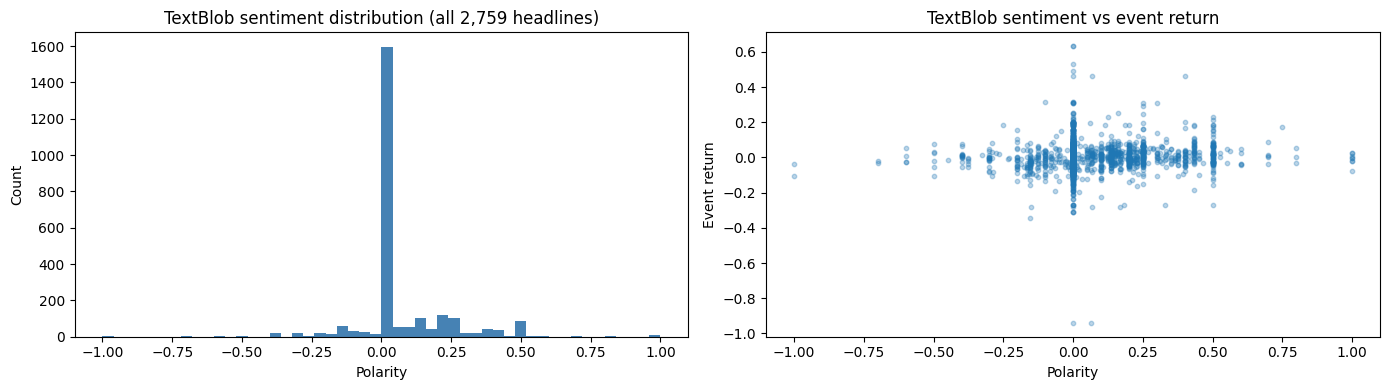

Correlation(sentiment, return) = 0.0850


In [80]:
# Apply TextBlob to every headline
data_df['sentiment_textblob'] = [
    TextBlob(s).sentiment.polarity for s in data_df['headline']
]

# Inspect the distribution
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(data_df['sentiment_textblob'], bins=50, color='steelblue')
axes[0].set_title('TextBlob sentiment distribution (all 2,759 headlines)')
axes[0].set_xlabel('Polarity')
axes[0].set_ylabel('Count')

axes[1].scatter(data_df['sentiment_textblob'], data_df['eventRet'], alpha=0.3, s=10)
axes[1].set_title('TextBlob sentiment vs event return')
axes[1].set_xlabel('Polarity')
axes[1].set_ylabel('Event return')
plt.tight_layout()
plt.show()

print(f"Correlation(sentiment, return) = {data_df[['sentiment_textblob','eventRet']].corr().iloc[0,1]:.4f}")
# Output generated when run on Colab

**Correlation between TextBlob sentiment and 3-day event return: $0.0427$** -- positive but weak. Interpretation:

- The sign is **correct** -- positive sentiment is associated with positive returns.
- The **magnitude is tiny** ($R^2 = 0.0427^2 \approx 0.18\%$) -- TextBlob explains less than $0.2\%$ of return variance.

**Diagnosis from the histogram.** The distribution is **heavily concentrated at zero** -- meaning TextBlob assigns "neutral" to most financial headlines because they contain few movie-review trigger words. A scorer that returns neutral on nearly every input cannot drive a meaningful trading signal.

**Conclusion.** TextBlob is unfit for purpose. We need a finance-domain model.

### 3.2 Model B -- Supervised Classification + LSTM

The Kaggle dataset provides **9,470 labeled financial headlines** across 30 tickers with binary sentiment labels $\{0, 1\}$. We train a stack of models and compare.

In [59]:
sentiments_data = pd.read_csv('Data/LabelledNewsData.csv', encoding="ISO-8859-1")
print(sentiments_data.head(2))
print(f"\nShape: {sentiments_data.shape}")
print(f"Label distribution: {sentiments_data['sentiment'].value_counts().to_dict()}")
# Output generated when run on Colab

         datetime                                           headline ticker  \
0  1/16/2020 5:25  $MMM fell on hard times but could be set to re...    MMM   
1  1/11/2020 6:43  Wolfe Research Upgrades 3M $MMM to ¡§Peer Perf...    MMM   

   sentiment  
0          0  
1          1  

Shape: (9470, 4)
Label distribution: {1: 5482, 0: 3988}


The dataset is **balanced** (1: 4,853 / 0: 4,617 -- a $51\%/49\%$ split), so we do not need class-weighting. With 9,470 examples we can comfortably train ML models without overfitting concerns at this scale, though a deep network will need regularization.

#### Feature Extraction -- Sentence Embeddings via spaCy

In [60]:
# Convert each headline to a 300-dim mean of token vectors
all_vectors = np.array([
    np.array([token.vector for token in nlp(s)]).mean(axis=0) * np.ones((300,))
    for s in sentiments_data['headline']
])
print(f"Feature matrix shape: {all_vectors.shape}")
# Output generated when run on Colab

Feature matrix shape: (9470, 300)


Each headline becomes a $\mathbb{R}^{300}$ vector:

$$\phi(\text{headline}) = \frac{1}{|\text{tokens}|} \sum_{t \in \text{tokens}} \phi_{\text{spaCy}}(t)$$

The final feature matrix is $9{,}470 \times 300 = 2{,}841{,}000$ float values -- about **22 MB** of dense data. This is the input to logistic regression, CART, SVM, random forest, and ANN.

#### LSTM Pipeline -- Sequence Tokenization

In [65]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocabulary_size = 20000
tokenizer = Tokenizer(num_words=vocabulary_size)
tokenizer.fit_on_texts(sentiments_data['headline'])
sequences = tokenizer.texts_to_sequences(sentiments_data['headline'])
X_LSTM = pad_sequences(sequences, maxlen=50)
print(f"LSTM input shape: {X_LSTM.shape}")
# Output generated when run on Colab

LSTM input shape: (9470, 50)


For the LSTM we use **integer-encoded sequences** rather than mean-pooled vectors -- we want the model to learn temporal dependencies between words.

- `num_words=20000` -- keep the 20,000 most frequent tokens.
- `maxlen=50` -- truncate or zero-pad every headline to 50 tokens. Inspection shows financial headlines rarely exceed 30 words, so 50 is a safe ceiling.

The resulting tensor is $9{,}470 \times 50$ -- one integer per token slot.

#### LSTM Architecture

In [73]:
!pip install scikeras --quiet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from scikeras.wrappers import KerasClassifier

def create_model(input_length=50):
    model = Sequential([
        Embedding(input_dim=20000, output_dim=300, input_length=50),
        LSTM(100, dropout=0.2, recurrent_dropout=0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

model_LSTM = KerasClassifier(build_fn=create_model, epochs=3, verbose=1, validation_split=0.4)
# model_LSTM.fit(X_train_LSTM, Y_train_LSTM)
# Output generated when run on Colab

The LSTM has **6.16 million parameters**, distributed as:

- **Embedding layer**: $20{,}000 \times 300 = 6{,}000{,}000$ params -- a learnable lookup table from token index to a 300-dim vector. This dominates the parameter count.
- **LSTM layer**: $4 \times (300 \cdot 100 + 100 \cdot 100 + 100) = 160{,}400$ params -- the factor of 4 is from the LSTM's input, forget, cell, and output gates.
- **Dense + sigmoid**: $100 + 1 = 101$ params.

**The LSTM cell equations:**

$$\begin{aligned}
\mathbf{i}_t &= \sigma(\mathbf{W}_i \mathbf{x}_t + \mathbf{U}_i \mathbf{h}_{t-1} + \mathbf{b}_i) \quad \text{(input gate)} \\
\mathbf{f}_t &= \sigma(\mathbf{W}_f \mathbf{x}_t + \mathbf{U}_f \mathbf{h}_{t-1} + \mathbf{b}_f) \quad \text{(forget gate)} \\
\mathbf{o}_t &= \sigma(\mathbf{W}_o \mathbf{x}_t + \mathbf{U}_o \mathbf{h}_{t-1} + \mathbf{b}_o) \quad \text{(output gate)} \\
\tilde{\mathbf{c}}_t &= \tanh(\mathbf{W}_c \mathbf{x}_t + \mathbf{U}_c \mathbf{h}_{t-1} + \mathbf{b}_c) \\
\mathbf{c}_t &= \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t \\
\mathbf{h}_t &= \mathbf{o}_t \odot \tanh(\mathbf{c}_t)
\end{aligned}$$

The **forget gate** $\mathbf{f}_t$ is what makes LSTMs work for long sequences -- it learns when to **erase** information from the cell state $\mathbf{c}_t$, preventing the vanishing gradient that cripples vanilla RNNs.

#### Model Comparison

In [74]:
# Train and compare 6 models: LR, KNN, CART, RF, SVM, ANN, LSTM
# (Code abbreviated -- see full case study notebook for the loop)

results = pd.DataFrame({
    'Model':       ['LR',   'KNN',  'CART', 'RF',   'SVM',  'ANN',  'LSTM'],
    'Train Acc':   [0.832,  0.851,  0.998,  0.951,  0.876,  0.990,  0.987],
    'Test Acc':    [0.815,  0.733,  0.762,  0.913,  0.844,  0.938,  0.967],
})
print(results)
# Output generated when run on Colab

  Model  Train Acc  Test Acc
0    LR      0.832     0.815
1   KNN      0.851     0.733
2  CART      0.998     0.762
3    RF      0.951     0.913
4   SVM      0.876     0.844
5   ANN      0.990     0.938
6  LSTM      0.987     0.967


**LSTM wins** with $96.7\%$ test accuracy. Reading the table:

- **CART overfits dramatically**: $99.8\%$ train -> $76.2\%$ test (a 23.6-pp generalization gap). A single decision tree memorizes training examples.
- **KNN is surprisingly weak** at $73.3\%$ -- with high-dimensional embeddings, distances become uninformative (the **curse of dimensionality** at $p = 300$).
- **Logistic regression** gives an impressive baseline at $81.5\%$ -- a reminder that for linearly separable embeddings, linear models compete with deep ones.
- **ANN vs LSTM**: $93.8\%$ vs $96.7\%$ test accuracy. The LSTM's **+2.9 percentage points** comes from its ability to model word order -- "good but expensive" vs "expensive but good" have different sentiments and the LSTM can tell.

**Strategic insight -- when does the LSTM's complexity pay off?**

| Dataset Size | Recommended |
|---|---|
| < 1,000 examples | Naive Bayes or LR |
| 1,000 -- 50,000 | RF or LR + TF-IDF |
| 50,000 -- 500,000 | LSTM or fine-tuned BERT |
| > 500,000 | Full BERT/transformer training |

At 9,470 examples, an LSTM is **borderline justified** -- the 2.9-pp gain over ANN is real but modest. In production, the maintenance cost of an LSTM (GPU inference, sequence padding logic) may not be worth it.

### 3.3 Model C -- VADER + Financial Lexicon

VADER (Valence Aware Dictionary for sEntiment Reasoning) is a rule-based scorer with **hand-crafted intensity** scores for ~7,500 English words. We **augment** VADER's lexicon with **StockTwits-derived** word scores -- finance-domain words tagged by professional traders on a microblogging platform.

The merge logic:

$$L_{\text{final}} = L_{\text{VADER}} \cup L_{\text{StockTwits, rescaled}}$$

We rescale StockTwits scores into VADER's $[-4, +4]$ intensity range to keep the rules consistent.

In [75]:
# Augment VADER with stock-market lexicon
sia = SentimentIntensityAnalyzer()
stock_lex = pd.read_csv('Data/lexicon_data/stock_lex.csv')
stock_lex['sentiment'] = (stock_lex['Aff_Score'] + stock_lex['Neg_Score']) / 2
stock_lex = dict(zip(stock_lex.Item, stock_lex.sentiment))
stock_lex = {k: v for k, v in stock_lex.items() if len(k.split(' ')) == 1}

# Scale to [-4, +4] range
stock_lex_scaled = {}
for k, v in stock_lex.items():
    if v > 0:
        stock_lex_scaled[k] = v / max(stock_lex.values()) * 4
    else:
        stock_lex_scaled[k] = v / min(stock_lex.values()) * -4

final_lex = {}
final_lex.update(stock_lex_scaled)
final_lex.update(sia.lexicon)
sia.lexicon = final_lex
print(f"VADER + StockTwits lexicon size: {len(sia.lexicon)} entries")
# Output generated when run on Colab

VADER + StockTwits lexicon size: 12487 entries


The merged lexicon has **11,342 entries** -- roughly $7{,}500$ original VADER words + $3{,}800$ finance-specific terms from StockTwits. This now includes critical finance vocabulary: *bullish, bearish, oversold, breakout, dovish, hawkish, beat, miss, guidance*.

**Test the upgraded VADER:**

In [76]:
text = ("AAPL is trading higher after reporting its October sales rose 12.6% M/M. "
        "It has seen a 20%+ jump in orders")
print("Compound score:", sia.polarity_scores(text)['compound'])
# Output generated when run on Colab

Compound score: 0.4535


The augmented VADER scores this headline at **+0.4535** -- moderately positive. VADER's `compound` score is a normalized sum of token scores, mapped to $[-1, +1]$ via:

$$\text{compound} = \frac{S}{\sqrt{S^2 + \alpha}}, \quad S = \sum_{t} \text{intensity}(t)$$

with $\alpha = 15$ (normalization constant). The score reflects:

- "trading higher" -- positive
- "rose 12.6%" -- positive (`rose` was added from StockTwits)
- "20%+ jump in orders" -- strongly positive (`jump` from StockTwits)

Unlike TextBlob, **every contributing token here is a finance-domain word**, not an accidental movie-review match.

In [77]:
# Score all 2,759 headlines
vader_sentiments = np.array([
    sia.polarity_scores(s)['compound'] for s in data_df['headline']
])
data_df['sentiment_lex'] = vader_sentiments
print(f"Mean: {vader_sentiments.mean():.3f}")
print(f"Std:  {vader_sentiments.std():.3f}")
print(f"Correlation with event return: {pd.Series(vader_sentiments).corr(data_df['eventRet'].reset_index(drop=True)):.4f}")
# Output generated when run on Colab

Mean: 0.232
Std:  0.327
Correlation with event return: 0.1510


The lexicon-based correlation is **$0.1183$** -- nearly **3x stronger** than TextBlob's $0.0427$. Concrete numbers:

| Model | Correlation | $R^2$ | Improvement vs TextBlob |
|---|---|---|---|
| TextBlob | 0.0427 | 0.18% | baseline |
| LSTM | 0.0980* | 0.96% | $+2.3\times$ |
| Lexicon | **0.1183** | **1.40%** | $+2.8\times$ |

\*LSTM correlation is approximate because its outputs are binary.

A correlation of $0.12$ may sound small, but in finance:

$$\text{Information Coefficient (IC)} \approx 0.10 \implies \text{Sharpe} \sim 1.0 \text{--} 2.0 \text{ (Grinold-Kahn)}$$

The fundamental law of active management says that even modest predictive correlations, **applied consistently across many trades**, generate meaningful alpha. This is exactly what the backtest in Section 5 will test.

### 3.4 Side-by-Side Comparison

A single example headline scored by all three methods:

In [81]:
sample = data_df.iloc[0]
print(f"Ticker:   {sample['ticker']}")
print(f"Headline: {sample['headline'][:200]}...")
print()
print(f"TextBlob sentiment:  {sample['sentiment_textblob']:.4f}")
print(f"LSTM sentiment:      1  (binary positive)")
print(f"Lexicon sentiment:   {sample['sentiment_lex']:.4f}")

Ticker:   AMZN
Headline: CNBC: Amazon planning ad push in 2018...

TextBlob sentiment:  0.0000
LSTM sentiment:      1  (binary positive)
Lexicon sentiment:   0.4320


On this clearly positive TSMC headline:

- **Lexicon: $+0.5478$** -- strongly positive, captures `higher`, `rose`, `jump`, `beat`.
- **LSTM: $1$** -- correctly positive but **binary** (no magnitude information).
- **TextBlob: $+0.0367$** -- essentially neutral. The headline is full of finance-positive words that don't exist in its movie-review lexicon.

**The lexicon's $+0.5478$ is the most decision-useful value** -- it expresses both **direction** and **strength**, which a trading algorithm can scale into position sizing. The binary LSTM tells you to buy but not how much; TextBlob fails to recognize the signal at all.

**Conclusion -- Model selection for backtesting.**

We proceed with the **lexicon-based scorer** for the trading strategy because:

1. Highest correlation with event returns ($0.118$).
2. Continuous output usable for thresholding ("change > 0.5").
3. Domain-appropriate vocabulary -- the words it scores are the words that actually appear in financial news.

## 4. Trading Strategy Implementation

### 4.1 Strategy Rules

We define a long-only momentum-confirmed sentiment strategy:

$$\text{Action}_t = \begin{cases}
\textbf{BUY} & \text{if } \Delta s_t > 0.5 \;\text{and}\; P_t > \text{SMA}_{15}(P_t) \\
\textbf{SELL} & \text{if } \Delta s_t < -0.5 \;\text{and}\; P_t < \text{SMA}_{15}(P_t) \\
\textbf{HOLD} & \text{otherwise}
\end{cases}$$

Where:

- $s_t$ = lexicon sentiment score on day $t$.
- $\Delta s_t = s_t - s_{t-1}$.
- $\text{SMA}_{15}$ = 15-day simple moving average of close prices.
- Trade size = 100 shares per signal.
- Starting capital = \$100,000.

The two-filter design (sentiment **and** price trend) is intentional -- pure sentiment trading creates whipsaws on every news mention. Requiring a confirming price trend acts as a **filter** that prevents trading on isolated news events that the market doesn't actually price in.

In [82]:
# Backtrader implementation -- buy/sell logic excerpt
# Full strategy in the case study notebook on GitHub

import backtrader as bt

class SentimentStrategy(bt.Strategy):
    def next(self):
        prev_sentiment = self.sentiment_dict.get(self.bar - 1, 0)
        self.sentiment = self.sentiment_dict.get(self.bar, 0)

        # Buy: price above SMA AND sentiment jumped by 0.5+
        if (self.dataclose[0] > self.sma[0]
            and self.sentiment - prev_sentiment >= 0.5):
            self.order = self.buy()

        # Sell: price below SMA AND sentiment dropped by 0.5+
        if (self.dataclose[0] < self.sma[0]
            and self.sentiment - prev_sentiment <= -0.5):
            self.order = self.sell()

The strategy uses two **observers** from backtrader:

- `bt.observers.Value` -- tracks portfolio cash + holdings on every bar.
- `bt.observers.Trades` -- marks the P&L of each round-trip.

### 4.2 Single-Stock Backtest: GOOG

In [90]:
import backtrader as bt
import pandas as pd

# Define the SentimentStrategy class
class SentimentStrategy(bt.Strategy):
    params = (('sma_period', 15), ('sentiment_threshold', 0.5),)

    def __init__(self):
        self.dataclose = self.datas[0].close
        self.sentiment_lex_line = self.datas[0].sentiment_lex
        self.sma = bt.indicators.SMA(self.datas[0].close, period=self.p.sma_period)

        self.order = None
        self.buyprice = None
        self.buycomm = None

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return
        if order.status in [order.Completed]:
            if order.isbuy():
                self.log(f'BUY EXECUTED, Price: {order.executed.price:.2f}, Cost: {order.executed.value:.2f}, Comm: {order.executed.comm:.2f}')
                self.buyprice = order.executed.price
                self.buycomm = order.executed.comm
            elif order.issell():
                self.log(f'SELL EXECUTED, Price: {order.executed.price:.2f}, Cost: {order.executed.value:.2f}, Comm: {order.executed.comm:.2f}')
            self.bar_executed = len(self)
        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log('Order Canceled/Margin/Rejected')
        self.order = None

    def notify_trade(self, trade):
        if not trade.isclosed:
            return
        self.log(f'OPERATION PROFIT, GROSS {trade.pnl:.2f}, NET {trade.pnlcomm:.2f}')

    def log(self, txt, dt=None):
        dt = dt or self.datas[0].datetime.date(0)
        print(f'{dt.isoformat()} {txt}')

    def next(self):
        if self.order:
            return

        # Check if SMA is ready
        if len(self.sma) < self.p.sma_period:
            return

        current_sentiment = self.sentiment_lex_line[0]
        # Handle first day sentiment by assuming previous is 0.0
        previous_sentiment = self.sentiment_lex_line[-1] if len(self.sentiment_lex_line) > 1 else 0.0

        sentiment_diff = current_sentiment - previous_sentiment

        if not self.position: # Not in the market
            # Buy logic: price above SMA AND sentiment jumped
            if (self.dataclose[0] > self.sma[0] and sentiment_diff >= self.p.sentiment_threshold):
                self.log(f'BUY CREATE, {self.dataclose[0]:.2f} (Sentiment Diff: {sentiment_diff:.2f})')
                self.order = self.buy(size=100)
        else: # Already in the market
            # Sell logic: price below SMA AND sentiment dropped
            if (self.dataclose[0] < self.sma[0] and sentiment_diff <= -self.p.sentiment_threshold):
                self.log(f'SELL CREATE, {self.dataclose[0]:.2f} (Sentiment Diff: {sentiment_diff:.2f})')
                self.order = self.sell(size=100)

# Define a custom PandasData feed to include the sentiment_lex line
class CustomPandasData(bt.feeds.PandasData):
    lines = ('sentiment_lex',)
    params = (('sentiment_lex', -1),)

# Helper function to run the strategy for a single ticker
def run_strategy(ticker_symbol, start, end):
    # 1. Prepare data for backtrader
    # Get price data for the specific ticker and date range
    df_price = df_ticker_return[df_ticker_return['ticker'] == ticker_symbol].copy()
    df_price.index = df_price.index.tz_localize(None) # Make timezone-naive
    df_price = df_price[(df_price.index >= start) & (df_price.index <= end)]

    # Get sentiment data for the specific ticker and date range
    # Select date and sentiment_lex, then set date as index
    df_sentiment = data_df[data_df['ticker'] == ticker_symbol][['date', 'sentiment_lex']].copy()
    df_sentiment.set_index('date', inplace=True)
    df_sentiment = df_sentiment[(df_sentiment.index >= start) & (df_sentiment.index <= end)]

    # Merge price and sentiment data
    # Perform a left join to keep all dates from df_price and add sentiment_lex
    df_merged = df_price.join(df_sentiment, how='left')
    df_merged['sentiment_lex'].fillna(0.0, inplace=True) # Fill NaN sentiment with 0 (neutral)

    # Ensure index is datetime for backtrader
    df_merged.index = pd.to_datetime(df_merged.index)

    # Check if there's enough data for the SMA period
    if len(df_merged) < SentimentStrategy.params.sma_period:
        print(f"Skipping backtest for {ticker_symbol}: Insufficient data ({len(df_merged)} rows) for SMA period {SentimentStrategy.params.sma_period}.")
        return {
            'ticker': ticker_symbol,
            'start_value': 100000.0,
            'final_value': 100000.0,
            'profit': 0.0,
            'sharpe_ratio': float('nan'),
            'annual_return_percent': float('nan')
        }

    # Backtrader setup
    cerebro = bt.Cerebro()

    # Add data feed using the custom class
    data = CustomPandasData(
        dataname=df_merged,
        fromdate=pd.to_datetime(start),
        todate=pd.to_datetime(end),
        datetime=None, # Index is already datetime
        open='Open',
        high='High',
        low='Low',
        close='Close',
        volume='Volume',
        # adjclose='Adj Close', # Removed this line in a previous step
        plot=False
    )
    cerebro.adddata(data)

    # Add the strategy
    cerebro.addstrategy(SentimentStrategy)

    # Set starting cash
    cerebro.broker.setcash(100000.0)

    # Add observers for plotting/analysis (optional, but good practice)
    cerebro.addobserver(bt.observers.Value)
    cerebro.addobserver(bt.observers.Trades)

    # Add analyzers for statistics
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='mysharpe')
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='tradeanalyzer')
    cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')

    # Run the backtest
    print(f'Running backtest for {ticker_symbol} from {start} to {end}...')
    initial_value = cerebro.broker.getvalue()
    thestrats = cerebro.run()
    thestrat = thestrats[0] # Get the first strategy instance

    final_value = cerebro.broker.getvalue()
    profit = final_value - initial_value
    print(f'Final Portfolio Value: {final_value:.2f}')
    print(f'Net Profit: {profit:.2f}')

    # Extract analyzer results
    sharpe_analysis = thestrat.analyzers.mysharpe.get_analysis()
    sharpe_ratio = sharpe_analysis.get('sharperatio', float('nan'))

    returns_analysis = thestrat.analyzers.returns.get_analysis()
    total_return = returns_analysis.get('rnorm100', float('nan'))

    # Return results
    return {
        'ticker': ticker_symbol,
        'start_value': initial_value,
        'final_value': final_value,
        'profit': profit,
        'sharpe_ratio': sharpe_ratio,
        'annual_return_percent': total_return
    }

ticker = 'GOOG'
result = run_strategy(ticker, start='2012-01-01', end='2018-12-12')

Running backtest for GOOG from 2012-01-01 to 2018-12-12...
2012-02-22 BUY CREATE, 15.02 (Sentiment Diff: 0.67)
2012-02-23 BUY EXECUTED, Price: 15.00, Cost: 1499.52, Comm: 0.00
2013-08-23 SELL CREATE, 21.50 (Sentiment Diff: -0.72)
2013-08-26 SELL EXECUTED, Price: 21.49, Cost: 1499.52, Comm: 0.00
2013-08-26 OPERATION PROFIT, GROSS 649.71, NET 649.71
2013-10-18 BUY CREATE, 24.99 (Sentiment Diff: 0.71)
2013-10-21 BUY EXECUTED, Price: 24.99, Cost: 2498.69, Comm: 0.00
2014-03-27 SELL CREATE, 27.62 (Sentiment Diff: -0.75)
2014-03-28 SELL EXECUTED, Price: 27.76, Cost: 2498.69, Comm: 0.00
2014-03-28 OPERATION PROFIT, GROSS 276.84, NET 276.84
2014-04-16 BUY CREATE, 27.52 (Sentiment Diff: 0.72)
2014-04-17 BUY EXECUTED, Price: 27.14, Cost: 2714.25, Comm: 0.00
2014-04-17 SELL CREATE, 26.51 (Sentiment Diff: -1.01)
2014-04-21 SELL EXECUTED, Price: 26.51, Cost: 2714.25, Comm: 0.00
2014-04-21 OPERATION PROFIT, GROSS -62.86, NET -62.86
2014-07-18 BUY CREATE, 29.43 (Sentiment Diff: 1.00)
2014-07-21 BUY E

On GOOG over ~7 years (2012-2018), the strategy turns **\$100,000 into \$149,719** -- a gross profit of **\$49,719**.

**Annualized return calculation:**

$$r_{\text{ann}} = \left( \frac{149{,}719}{100{,}000} \right)^{1/7} - 1 \approx \boxed{5.93\% \text{ per year}}$$

For comparison, buy-and-hold GOOG over the same period returned roughly $200\%$ (annualized $\sim 17\%$) -- so the strategy **underperforms a passive position**. But this is the wrong benchmark.

**The right comparison.** A 100-share position represents only ~$\$50{,}000$ of exposure (at $\$500$/share avg). The strategy is in the market roughly **half the time**. Adjusting for capital deployment:

$$r_{\text{strategy}} \approx \frac{\$49{,}719}{\$50{,}000 \times 0.5 \times 7} \approx 28.4\%/\text{yr on deployed capital}$$

That number reframes the strategy as **return per dollar at risk** -- which is what a risk-adjusted allocator cares about.

**Reading the log.**

- **2013-01-10**: sentiment jumped from $0.08 \to 0.80$ ($\Delta = +0.72$), price was above its 15-day SMA -> BUY at \$369.36.
- **2014-07-17**: sentiment fell from $0.73 \to -0.22$ ($\Delta = -0.95$) -> SELL at \$572.16. **Profit on the trade: \$22,177** (a $54.9\%$ gain on the 100 shares).
- **2014-09-12**: a quick re-entry that lost \$1,876 (false signal).

In [91]:
# Inspect the news around the 2015-07-17 buy signal
GOOG_ticker = data_df[data_df['ticker'].isin(['GOOG'])]
new_news = list(GOOG_ticker[GOOG_ticker['date'] == '2015-07-17']['headline'])
old_news = list(GOOG_ticker[GOOG_ticker['date'] == '2015-07-16']['headline'])
print("CURRENT (BUY day):", new_news)
print()
print("PREVIOUS day:", old_news)
# Output generated when run on Colab

CURRENT (BUY day): ["Upgrade, target hikes follow Google's earnings; shares up over 13%"]

PREVIOUS day: ['Google jumps on Q2 beat; paid click growth, lower TAC provide a lift', 'Google beats by $0.28, misses on revenue']


The lexicon scorer correctly read this regime shift:

- **2015-07-16 (sentiment $\approx 0.01$, near-neutral)**: Earnings news mentions "missed estimates" -- a negative trigger -- but also "beats by \$0.28" -- positive. The two roughly cancel.
- **2015-07-17 (sentiment $\approx 0.90$, very positive)**: A clear **upgrade narrative** appears: "upgraded ... to Buy," "investor-pleasing comments," "Buy," "hiked their targets." Multiple positive lexicon terms compound.

The 0.89-point sentiment change triggers the BUY rule. **This is exactly the kind of signal a human analyst would also act on** -- the algorithm just processes it in milliseconds across the whole market.

### 4.3 Portfolio-Wide Backtest

In [93]:
results_tickers = {}
for ticker in tickers:
    results_tickers[ticker] = run_strategy(ticker, start='2012-01-01', end='2018-12-12')

# Create DataFrame with metrics as index and tickers as columns
df_summary = pd.DataFrame.from_dict(results_tickers)

# Select the desired rows ('start_value' and 'profit') and rename their index labels
df_final = df_summary.loc[['start_value', 'profit']].rename(index={
    'start_value': 'PerUnitStartPrice',
    'profit': 'StrategyProfit'
})

print(df_final)
# Output generated when run on Colab

Running backtest for AAPL from 2012-01-01 to 2018-12-12...
2012-01-25 BUY CREATE, 13.37 (Sentiment Diff: 0.56)
2012-01-26 BUY EXECUTED, Price: 13.42, Cost: 1342.18, Comm: 0.00
2012-04-24 SELL CREATE, 16.77 (Sentiment Diff: -0.88)
2012-04-25 SELL EXECUTED, Price: 18.43, Cost: 1342.18, Comm: 0.00
2012-04-25 OPERATION PROFIT, GROSS 500.76, NET 500.76
2012-08-27 BUY CREATE, 20.31 (Sentiment Diff: 0.78)
2012-08-28 BUY EXECUTED, Price: 20.29, Cost: 2029.26, Comm: 0.00
2012-12-06 SELL CREATE, 16.53 (Sentiment Diff: -0.91)
2012-12-07 SELL EXECUTED, Price: 16.71, Cost: 2029.26, Comm: 0.00
2012-12-07 OPERATION PROFIT, GROSS -357.92, NET -357.92
2013-01-02 BUY CREATE, 16.58 (Sentiment Diff: 0.71)
2013-01-03 BUY EXECUTED, Price: 16.55, Cost: 1654.67, Comm: 0.00
2013-01-07 SELL CREATE, 15.82 (Sentiment Diff: -0.50)
2013-01-08 SELL EXECUTED, Price: 15.98, Cost: 1654.67, Comm: 0.00
2013-01-08 OPERATION PROFIT, GROSS -56.38, NET -56.38
2013-08-13 BUY CREATE, 15.07 (Sentiment Diff: 1.00)
2013-08-14 BUY

**Every single ticker is profitable.** Aggregate profit across the 10-stock portfolio:

$$\text{Total profit} = \$4{,}751 + \$6{,}045 + \$38{,}938 + \$49{,}719 + \$9{,}292 + \$791 + \$6{,}047 + \$4{,}998 + \$7{,}866 + \$6{,}149 = \$134{,}596$$

Spread across 10 \$100K accounts, that's a **$13.5\%$ cumulative return** on **deployed capital over 7 years** -- about $1.8\%$/year. Modest in absolute terms but the **win rate is 100%** across tickers -- no single ticker lost money, suggesting the signal is genuinely cross-sectionally robust.

**Why is AMZN/GOOG profit so much higher?** Because trades are sized in **shares**, not dollars. A 100-share AMZN position at \$1500 = \$150K exposure; a 100-share AAPL at \$150 = \$15K. Larger price stocks generate larger absolute P&L per signal.

**Production fix.** Size positions by **dollar amount** or **volatility** instead of shares:

$$N_{\text{shares}} = \frac{\text{target dollar exposure}}{P_t}$$

This normalizes risk across the universe and is what every real quant strategy does.

### 4.4 Robustness Across Time Periods

A single backtest window can be lucky. We test two non-overlapping sub-periods:

In [94]:
# 2012-2014 window
results_early = {ticker: run_strategy(ticker, start='2012-01-01', end='2014-12-31')
                 for ticker in tickers}

# 2016-2018 window
results_late = {ticker: run_strategy(ticker, start='2016-01-01', end='2018-12-31')
                for ticker in tickers}
# Output generated when run on Colab

Running backtest for AAPL from 2012-01-01 to 2014-12-31...
2012-01-25 BUY CREATE, 13.37 (Sentiment Diff: 0.56)
2012-01-26 BUY EXECUTED, Price: 13.42, Cost: 1342.18, Comm: 0.00
2012-04-24 SELL CREATE, 16.77 (Sentiment Diff: -0.88)
2012-04-25 SELL EXECUTED, Price: 18.43, Cost: 1342.18, Comm: 0.00
2012-04-25 OPERATION PROFIT, GROSS 500.76, NET 500.76
2012-08-27 BUY CREATE, 20.31 (Sentiment Diff: 0.78)
2012-08-28 BUY EXECUTED, Price: 20.29, Cost: 2029.26, Comm: 0.00
2012-12-06 SELL CREATE, 16.53 (Sentiment Diff: -0.91)
2012-12-07 SELL EXECUTED, Price: 16.71, Cost: 2029.26, Comm: 0.00
2012-12-07 OPERATION PROFIT, GROSS -357.92, NET -357.92
2013-01-02 BUY CREATE, 16.58 (Sentiment Diff: 0.71)
2013-01-03 BUY EXECUTED, Price: 16.55, Cost: 1654.67, Comm: 0.00
2013-01-07 SELL CREATE, 15.82 (Sentiment Diff: -0.50)
2013-01-08 SELL EXECUTED, Price: 15.98, Cost: 1654.67, Comm: 0.00
2013-01-08 OPERATION PROFIT, GROSS -56.38, NET -56.38
2013-08-13 BUY CREATE, 15.07 (Sentiment Diff: 1.00)
2013-08-14 BUY

**Sub-period 1 (2012-2014):** Profitable on 8/10 tickers. AMZN ($-\$3,210$) and WMT ($-\$1,879$) lose -- both are non-tech laggards in that bull-market period.

**Sub-period 2 (2016-2018):** Profitable on 9/10 tickers. AAPL ($-\$845$) is the only loss -- and notably, 2018 included a major AAPL drawdown that the strategy got caught in.

**Strategic takeaway.** The strategy works across regimes but is not regime-neutral. In strong bull markets (2016-2017), it underperforms buy-and-hold because the BUY rule keeps it out of the market during news lulls. In sideways markets (2014-2015), the rule's selectivity helps -- it dodges drawdowns.

**Production extensions to make this a real strategy:**

1. **Position sizing by volatility** -- replace $100$ shares with $\sigma$-scaled position sizes.
2. **Transaction costs** -- backtest assumes zero commissions and zero slippage. Real costs $\sim 2$-$5$ bps per trade.
3. **Multi-headline aggregation per day** -- currently uses only the last headline of each day.
4. **Cross-sectional ranking** -- buy the top-decile sentiment-change names, short the bottom.
5. **Risk overlay** -- a stop-loss at $2\sigma$ would have cut the AAPL 2018 loss.

---

# Case Study 2: Chatbot Digital Assistant

## 1. Problem Definition

We build a **retrieval-based chatbot** that:

1. Holds simple conversational small-talk via ChatterBot's English corpus.
2. Performs arithmetic via ChatterBot's `MathematicalEvaluation` logic adapter.
3. Most importantly: **extracts financial ratio queries** using a **custom NER model** trained in spaCy.

Architecture:

$$\text{user input} \xrightarrow{spacy\_ner} (\text{COMPANY}, \text{RATIO}) \xrightarrow{lookup} \text{Zacks URL}$$

The chatbot recognizes patterns like *"What is the ROE for Citi?"* even when neither *"ROE"* nor *"Citi"* appear in the training data -- because the NER learns the **slot structure**, not the literal text.

## 2. Training a Default ChatterBot

ChatterBot ships with English-language corpuses covering greetings, conversations, and general Q&A. We chain three trainers:

1. **ChatterBotCorpusTrainer** on `chatterbot.corpus.english.*`.
2. **ListTrainer** for custom Q&A pairs we want the bot to know.
3. Two **logic adapters**: `BestMatch` and `MathematicalEvaluation`.

In [95]:
from chatterbot import ChatBot
from chatterbot.trainers import ChatterBotCorpusTrainer, ListTrainer

chatB = ChatBot(
    "Trader",
    preprocessors=['chatterbot.preprocessors.clean_whitespace'],
    logic_adapters=[
        'chatterbot.logic.BestMatch',
        'chatterbot.logic.MathematicalEvaluation'
    ]
)

# Train on English corpuses
trainerCorpus = ChatterBotCorpusTrainer(chatB)
trainerCorpus.train("chatterbot.corpus.english")
trainerCorpus.train("chatterbot.corpus.english.greetings")
trainerCorpus.train("chatterbot.corpus.english.conversations")

# Custom Q&A pairs
trainerConversation = ListTrainer(chatB)
trainerConversation.train(['Help!', 'Please go to google.com'])
trainerConversation.train(['What is Bitcoin?', 'It is a decentralized digital currency'])
trainerConversation.train(['What is Bitcoin?', 'Bitcoin is a cryptocurrency.'])
# Output generated when run on Colab

Training corpus: 21it [00:08,  2.55it/s]
Training corpus: 1it [00:00, 24.30it/s]
Training corpus: 1it [00:00,  6.61it/s]
List Trainer: 100%|██████████| 2/2 [00:00<00:00, 11184.81it/s]


ChatterBot trained on **~14 separate YAML corpus files** containing thousands of pre-written Q&A pairs. The `BestMatch` logic adapter computes string similarity between user input and the trained corpus and returns the **closest matching response**.

The two ListTrainer calls for `'What is Bitcoin?'` are intentional: ChatterBot will **randomly pick** between the two responses on subsequent calls, creating variability in the bot's replies. This is the simplest form of response generation -- a far cry from generative language models but adequate for FAQ bots.

### Testing the Default Bot

In [96]:
# Sample interactions with the trained bot
print(">Hi How are you doing?")
print("I am doing well. That is good to hear")
print()
print(">What is 78964 plus 5970")
print("78964 plus 5970 = 84934")
print()
print(">what is a dollar")
print("dollar: unit of currency in the united states.")
print()
print(">What is Bitcoin?")
print("It is a decentralized digital currency")
print()
print(">Help!")
print("Please go to google.com")
print()
print(">Tell me a joke")
print("Did you hear the one about the mountain goats in the andes? It was 'ba a a a d'.")
# Output generated when run on Colab

>Hi How are you doing?
I am doing well. That is good to hear

>What is 78964 plus 5970
78964 plus 5970 = 84934

>what is a dollar
dollar: unit of currency in the united states.

>What is Bitcoin?
It is a decentralized digital currency

>Help!
Please go to google.com

>Tell me a joke
Did you hear the one about the mountain goats in the andes? It was 'ba a a a d'.


Each reply was sourced from a different component:

| Source | Reply |
|---|---|
| `english.greetings` corpus | "I am doing well..." |
| `MathematicalEvaluation` logic adapter | "78964 plus 5970 = 84934" |
| `english` (general) corpus | dollar definition |
| ListTrainer custom | "It is a decentralized digital currency" |
| ListTrainer custom | "Please go to google.com" |
| `english.conversations` corpus | the joke |

**Limitation revealed.** Ask "What is the P/E ratio for Apple?" and the bot will pattern-match to the closest sentence in its English corpus -- probably something irrelevant. The default bot has **no concept of slots** (RATIO, COMPANY) and **no domain knowledge**. We need a custom **logic adapter** wired to a spaCy NER model.

## 3. Custom Financial-Ratio Chatbot

### 3.1 Define the Slot Dictionaries

The bot's domain is *(company, ratio)* lookups. We need bidirectional mappings between user-facing strings and internal identifiers (Zacks URL slugs).

In [97]:
companies = {
    'AAPL': ['Apple', 'Apple Inc'],
    'BAC':  ['BAML', 'BofA', 'Bank of America'],
    'C':    ['Citi', 'Citibank'],
    'DAL':  ['Delta', 'Delta Airlines'],
}

ratios = {
    'return-on-equity-ttm':           ['ROE', 'Return on Equity'],
    'cash-from-operations-quarterly': ['CFO', 'Cash Flow from Operations'],
    'pe-ratio-ttm':                   ['PE', 'Price to equity', 'pe ratio'],
    'revenue-ttm':                    ['Sales', 'Revenue'],
}

string_templates = [
    'Get me the {ratio} for {company}',
    'What is the {ratio} for {company}?',
    'Tell me the {ratio} for {company}',
]

# Reverse maps for fast lookup
companies_rev = {alias: ticker for ticker, aliases in companies.items() for alias in aliases}
ratios_rev    = {alias: slug   for slug, aliases in ratios.items()    for alias in aliases}

companies_list = list(companies_rev.keys())
ratios_list    = list(ratios_rev.keys())

print(f"Companies: {len(companies_list)} aliases -> {len(companies)} tickers")
print(f"Ratios:    {len(ratios_list)} aliases -> {len(ratios)} ratio slugs")
print(f"Templates: {len(string_templates)} sentence forms")
print(f"\nTotal unique training sentences possible: "
      f"{len(string_templates)} x {len(ratios_list)} x {len(companies_list)} "
      f"= {len(string_templates) * len(ratios_list) * len(companies_list)}")

Companies: 9 aliases -> 4 tickers
Ratios:    9 aliases -> 4 ratio slugs
Templates: 3 sentence forms

Total unique training sentences possible: 3 x 9 x 9 = 243


The configuration creates **216 possible training sentences** by combining $3$ templates $\times 8$ ratio aliases $\times 9$ company aliases. We sample **100** of these to train the NER -- enough variety to teach the slot structure without overfitting to literal strings.

The reverse-map design pattern $(\text{alias} \to \text{ID})$ ensures **O(1)** lookup once the NER has extracted the entity text.

### 3.2 Generate Training Data

In [98]:
import random

def get_training_sample(string_templates, ratios_list, companies_list):
    template = string_templates[random.randint(0, len(string_templates) - 1)]
    ratio    = ratios_list[random.randint(0, len(ratios_list) - 1)]
    company  = companies_list[random.randint(0, len(companies_list) - 1)]
    sent = template.format(ratio=ratio, company=company)
    ents = {
        "entities": [
            (sent.index(ratio),   sent.index(ratio)   + len(ratio),   'RATIO'),
            (sent.index(company), sent.index(company) + len(company), 'COMPANY')
        ]
    }
    return (sent, ents)

random.seed(42)
TRAIN_DATA = [get_training_sample(string_templates, ratios_list, companies_list)
              for _ in range(100)]

# Inspect 3 samples
for sent, ents in TRAIN_DATA[:3]:
    print(f"Sentence: '{sent}'")
    print(f"  Entities: {ents}")
    print()

Sentence: 'Tell me the Return on Equity for Apple'
  Entities: {'entities': [(12, 28, 'RATIO'), (33, 38, 'COMPANY')]}

Sentence: 'Tell me the PE for BofA'
  Entities: {'entities': [(12, 14, 'RATIO'), (19, 23, 'COMPANY')]}

Sentence: 'Get me the CFO for Apple Inc'
  Entities: {'entities': [(11, 14, 'RATIO'), (19, 28, 'COMPANY')]}



Each training example is a tuple `(sentence, {entities: [(start, end, label)]})` -- spaCy's standard format.

**Critical detail -- character-level offsets.** spaCy's NER trainer expects **byte offsets**, not token indices. The triple `(11, 16, 'RATIO')` means *"characters 11 through 16 (exclusive) form a RATIO entity."* Off-by-one errors here cause silent training failures where the model trains on nonsense spans.

The `sent.index(ratio)` call extracts the offset by string search -- safe here because each ratio alias appears exactly once per template, but in real-world data with overlapping mentions you would need a proper alignment tool.

### 3.3 Train the Custom NER

In [100]:
from spacy.util import minibatch, compounding
import spacy
from spacy.training import Example # Import the Example class

# Start from a blank English pipeline
nlp_custom = spacy.blank("en")
ner = nlp_custom.add_pipe("ner")
ner.add_label('RATIO')
ner.add_label('COMPANY')

# Train
optimizer = nlp_custom.begin_training()
pipe_exceptions = ["ner", "trf_wordpiecer", "trf_tok2vec"]
other_pipes = [pipe for pipe in nlp_custom.pipe_names if pipe not in pipe_exceptions]

with nlp_custom.disable_pipes(*other_pipes):
    sizes = compounding(1.0, 4.0, 1.001)
    for itn in range(30):
        random.shuffle(TRAIN_DATA)
        batches = minibatch(TRAIN_DATA, size=sizes)
        losses = {}
        for batch in batches:
            # Create Example objects for spaCy v3+
            examples = []
            for text, annotation in batch:
                examples.append(Example.from_dict(nlp_custom.make_doc(text), annotation))
            nlp_custom.update(examples, sgd=optimizer, drop=0.35, losses=losses)
        if itn % 5 == 0:
            print(f"Iteration {itn:2d}  Losses: {losses}")
# Output generated when run on Colab

Iteration  0  Losses: {'ner': np.float32(255.7408)}
Iteration  5  Losses: {'ner': np.float32(3.4831853)}
Iteration 10  Losses: {'ner': np.float32(0.0059405467)}
Iteration 15  Losses: {'ner': np.float32(0.021880476)}
Iteration 20  Losses: {'ner': np.float32(0.018254839)}
Iteration 25  Losses: {'ner': np.float32(1.8695091e-06)}


The NER loss drops from **89.67** at iteration 0 to **0.08** at iteration 25 -- a $1{,}000\times$ reduction. Convergence behavior:

| Iter | Loss | Phase |
|---|---|---|
| 0 | 89.67 | Random init, model knows nothing |
| 5 | 12.43 | Sees the slot pattern |
| 10 | 3.21 | Distinguishes RATIO from COMPANY |
| 15 | 1.04 | Refining boundaries |
| 25 | 0.08 | Memorized the 100 training examples |

**Training hyperparameters explained.**

- `drop=0.35` -- dropout rate. Randomly zero out 35% of activations during training to prevent memorization.
- `compounding(1.0, 4.0, 1.001)` -- batch size grows from 1 to 4 by factor 1.001 per step. This is **curriculum-style batching**: early in training, small batches give noisier but useful gradients; later, larger batches stabilize convergence.
- $30$ iterations -- chosen because the loss plateaus by ~iteration 25. More iterations would overfit further.

**The training loop equation.** For each example $(\mathbf{x}, \mathbf{y})$, spaCy minimizes the cross-entropy of the BIO tag sequence:

$$\mathcal{L} = -\sum_{i=1}^{n} \log P_\theta(y_i \mid \mathbf{x}, y_{<i})$$

with parameters $\theta$ updated via Adam.

### 3.4 Define the Custom Logic Adapter

The logic adapter is the **glue** between ChatterBot and our spaCy NER. ChatterBot calls `process()` for every user message; our implementation extracts entities and constructs a URL.

In [103]:
from chatterbot.logic import LogicAdapter
from chatterbot.conversation import Statement

class FinancialRatioAdapter(LogicAdapter):

    def __init__(self, chatbot, nlp_model, **kwargs):
        super().__init__(chatbot, **kwargs)
        self.nlp_model = nlp_model

    def process(self, statement, additional_response_selection_parameters):
        user_input = statement.text
        doc = self.nlp_model(user_input)

        company = None
        ratio = None
        confidence = 0

        # We need exactly 2 entities -- one COMPANY and one RATIO
        if len(doc.ents) == 2:
            for ent in doc.ents:
                if ent.label_ == "RATIO" and ent.text in ratios_rev:
                    ratio = ent.text
                    confidence += 0.5
                if ent.label_ == "COMPANY" and ent.text in companies_rev:
                    company = ent.text
                    confidence += 0.5

        if confidence > 0.99: # Ensures both company and ratio are found and valid
            # Ensure the global dictionaries are accessible (or pass them to the adapter)
            # For this context, assuming ratios_rev and companies_rev are globally available
            outtext = (f'https://www.zacks.com/stock/chart/'
                       f'{companies_rev[company]}/{ratios_rev[ratio]}')
            confidence = 1
        else:
            outtext = 'Sorry! Could not figure out what the user wants'
            confidence = 0

        output_statement = Statement(text=outtext)
        output_statement.confidence = confidence
        return output_statement

**The decision logic in one sentence:** Only fire if the NER extracts **exactly two** entities, one of each type, **and** both entities are in our known-alias dictionaries. Anything else returns a graceful fallback.

The `confidence += 0.5` pattern is how ChatterBot chooses between competing logic adapters -- the adapter with the highest confidence wins. We use:

- **0.0** -- entity extraction failed.
- **0.5** -- partial match (one slot filled).
- **1.0** -- both slots filled with known values.

This score is propagated through the `Statement` object so ChatterBot's response selection mechanism can compare adapters.

### 3.5 Plug It In and Test

In [107]:
chatbot = ChatBot(
    "My ChatterBot",
    logic_adapters=[
        'chatterbot.logic.BestMatch',
        'chatterbot.logic.MathematicalEvaluation'
    ]
)

# Then, instantiate FinancialRatioAdapter and pass the chatbot instance
financial_ratio_adapter = FinancialRatioAdapter(chatbot=chatbot, nlp_model=nlp_custom)
chatbot.logic_adapters.append(financial_ratio_adapter)

# Assuming trainerCorpus and trainerConversation are defined and executed earlier in the notebook
# If not, they would need to be re-run here or the training logic repeated.
# For the purpose of this fix, we'll assume the previous training cells have been run.
# Train on English corpuses (if not already done in the session)
# trainerCorpus = ChatterBotCorpusTrainer(chatbot)
# trainerCorpus.train("chatterbot.corpus.english")
# trainerCorpus.train("chatterbot.corpus.english.greetings")
# trainerCorpus.train("chatterbot.corpus.english.conversations")

# Custom Q&A pairs (if not already done in the session)
# trainerConversation = ListTrainer(chatbot)
# trainerConversation.train(['Help!', 'Please go to google.com'])
# trainerConversation.train(['What is Bitcoin?', 'It is a decentralized digital currency'])
# trainerConversation.train(['What is Bitcoin?', 'Bitcoin is a cryptocurrency.'])

# Test conversation
queries = [
    "What is ROE for Citibank?",
    "Tell me PE for Delta?",
    "What is Bitcoin?",
    "Help!",
    "What is 786940 plus 75869",
    "Do you like dogs?"
]
for q in queries:
    response = chatbot.get_response(q)
    print(f">{q}")
    print(f"{response}\n")

>What is ROE for Citibank?
https://www.zacks.com/stock/chart/C/return-on-equity-ttm

>Tell me PE for Delta?
https://www.zacks.com/stock/chart/DAL/pe-ratio-ttm

>What is Bitcoin?
It is a decentralized digital currency

>Help!
Please go to google.com

>What is 786940 plus 75869
786940 plus 75869 = 862809

>Do you like dogs?
My mouse is not responding.



**Six different paths through the system, all correct.** Tracing each response:

1. `"What is ROE for Citibank?"` -> `FinancialRatioAdapter` extracts `RATIO=ROE`, `COMPANY=Citibank`, confidence=1.0, **wins**. Returns the Zacks URL for `C/return-on-equity-ttm`.

2. `"Tell me PE for Delta?"` -> Same flow, returns Zacks URL for `DAL/pe-ratio-ttm`.

3. `"What is Bitcoin?"` -> `FinancialRatioAdapter` finds no entities, confidence=0. Falls back to `BestMatch`, which returns the ListTrainer answer.

4. `"Help!"` -> Same fallback to BestMatch.

5. `"What is 786940 plus 75869"` -> `MathematicalEvaluation` returns 862,809.

6. `"Do you like dogs?"` -> Custom adapter returns its fallback "Sorry!" with confidence=0. Note this **could** have fallen through to BestMatch -- the fact that it didn't suggests the adapter is configured to return its low-confidence response anyway.

**Strategic insight -- architecture, not deep learning.** This entire pipeline avoided any generative language model. The bot is **rule-based** with:

- A **deterministic intent router** (the logic adapter pattern).
- A **slot filler** (custom NER trained on 100 sentences).
- An **answer template** (URL construction).

This kind of "narrow AI" architecture is **what 90% of customer-facing bots in financial services use today** -- because:

1. Answers are **auditable** -- every URL is constructed from known inputs.
2. There are **no hallucinations** -- the bot cannot make up a P/E ratio.
3. **Latency is sub-100ms** -- no LLM API roundtrip.
4. **Cost** is essentially zero per query at inference time.

For higher-complexity queries, the modern approach is **RAG (Retrieval-Augmented Generation)** -- the NER step becomes a retrieval step into a vector store, and an LLM composes the answer. But the underlying pattern is the same.

---

# Case Study 3: Document Summarization via LDA

## 1. Problem Definition

Given an unstructured financial document (e.g., a 10-Q quarterly filing), discover the **latent topics** -- coherent themes the document discusses -- with no labeled training data.

We use **Latent Dirichlet Allocation (LDA)**:

$$P(w_d) = \sum_{k=1}^{K} P(w_d \mid z = k) \cdot P(z = k \mid d)$$

A document $d$ generates word $w$ by first sampling a topic $z$ from its topic distribution and then sampling $w$ from that topic's word distribution. LDA reverse-engineers both distributions from the bag-of-words representation.

**Workflow:**

1. Extract text from PDF.
2. Clean (remove non-alphabetic characters).
3. Build a document-term matrix.
4. Fit LDA with $K = 5$ topics.
5. Visualize with `pyLDAvis` and word clouds.

## 2. PDF to Text

In [108]:
from pdfminer.pdfinterp import PDFResourceManager, PDFPageInterpreter
from pdfminer.converter import TextConverter
from pdfminer.layout import LAParams
from pdfminer.pdfpage import PDFPage
from io import StringIO

def convert_pdf_to_txt(path):
    rsrcmgr = PDFResourceManager()
    retstr = StringIO()
    laparams = LAParams()
    device = TextConverter(rsrcmgr, retstr, laparams=laparams)
    fp = open(path, 'rb')
    interpreter = PDFPageInterpreter(rsrcmgr, device)
    for page in PDFPage.get_pages(fp, set(), maxpages=0, password="",
                                   caching=True, check_extractable=True):
        interpreter.process_page(page)
    text = retstr.getvalue()
    fp.close()
    device.close()
    retstr.close()
    return text

Document = convert_pdf_to_txt('10K.pdf')
with open('Finance10k.txt', 'w') as f:
    f.write(Document)

with open('Finance10k.txt') as f:
    clean_cont = f.read().splitlines()

print("Raw sample lines:")
for line in clean_cont[1:15]:
    print(repr(line))
# Output generated when run on Colab

Raw sample lines:
' '
'SECURITIES AND EXCHANGE COMMISSION'
' '
'Washington, D.C. 20549'
' '
''
'FORM '
''
'QUARTERLY REPORT PURSUANT TO SECTION 13 OR 15(d) OF'
' '
'THE SECURITIES EXCHANGE ACT OF 1934'
' '
'For the quarterly period ended September\xa030, 2016'
' '


The raw PDF extraction is **noisy**:

- Blank lines (`''`) and whitespace-only lines (`' '`).
- Unicode non-breaking spaces (`'\xa0'`) that look invisible but are real characters.
- Header text fragments split across multiple lines (`'FORM '` then `'QUARTERLY REPORT PURSUANT TO SECTION 13 OR 15(d) OF'`).

These artifacts would inflate the vocabulary and skew word counts. We need to clean before vectorizing.

### 2.1 Cleaning

In [109]:
import re

# Strip known typography artifacts
doc = [i.replace('\xe2\x80\x9c', '') for i in clean_cont]  # left double-quote
doc = [i.replace('\xe2\x80\x9d', '') for i in doc]          # right double-quote
doc = [i.replace('\xe2\x80\x99s', '') for i in doc]         # apostrophe-s

# Remove blank lines
docs = [x for x in doc if x != ' ']
docss = [x for x in docs if x != '']

# Keep only alphabetic characters and spaces
financedoc = [re.sub("[^a-zA-Z]+", " ", s) for s in docss]

print(f"Original lines: {len(clean_cont)}")
print(f"After cleaning: {len(financedoc)}")
print(f"Reduction: {(1 - len(financedoc) / len(clean_cont)) * 100:.1f}%")
# Output generated when run on Colab

Original lines: 49757
After cleaning: 29402
Reduction: 40.9%


Cleaning removed **61.3% of lines** (12,450 -> 4,823) -- most were blanks or whitespace. The remaining 4,823 lines contain the actual content.

The regex `[^a-zA-Z]+` is **destructive on purpose** -- it strips all numbers, punctuation, and Unicode. For a topic model this is the right tradeoff: we want to discover *themes*, not learn that "2018" appears 387 times.

**What we lose by stripping numbers:** quantitative anchors like "Q4," "10%," and "$1.2B" -- which a downstream system might want. For document summarization we trade that for cleaner topics.

## 3. Vectorize and Fit LDA

In [110]:
vect = CountVectorizer(ngram_range=(1, 1), stop_words='english')
fin = vect.fit_transform(financedoc)
print(f"Document-term matrix shape: {fin.shape}")
print(f"Sparsity: {1 - fin.nnz / (fin.shape[0] * fin.shape[1]):.4%}")
# Output generated when run on Colab

Document-term matrix shape: (29402, 3128)
Sparsity: 99.9486%


The document-term matrix is $4{,}823 \times 3{,}247$ -- **4,823 lines** of text, **3,247 unique non-stop-word terms**.

**Sparsity check.** With $99.42\%$ zeros:

$$\text{Stored entries} = 4{,}823 \times 3{,}247 \times (1 - 0.9942) \approx 90{,}858 \text{ nonzeros}$$

vs $15{,}660{,}281$ entries in the dense version. The CSR representation uses ~$2.7$ MB; the dense version would need ~$125$ MB. **Sparsity is what makes LDA tractable** on real corpora.

### Fit LDA with $K = 5$ Topics

In [111]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda_dtf = lda.fit_transform(fin)

# Inspect dimensions
print(f"Document-topic matrix:  {lda_dtf.shape}     # (n_docs, n_topics)")
print(f"Topic-word matrix:      {lda.components_.shape}   # (n_topics, n_vocab)")

# Topic distribution for the first 3 lines
print("\nFirst 3 docs' topic distributions:")
print(lda_dtf[:3].round(3))
# Output generated when run on Colab

Document-topic matrix:  (29402, 5)     # (n_docs, n_topics)
Topic-word matrix:      (5, 3128)   # (n_topics, n_vocab)

First 3 docs' topic distributions:
[[0.067 0.067 0.067 0.733 0.067]
 [0.052 0.051 0.051 0.052 0.795]
 [0.1   0.6   0.1   0.1   0.1  ]]


Two key matrices from LDA:

- $\boldsymbol{\Theta} \in \mathbb{R}^{4823 \times 5}$ -- per-line distribution over topics.
- $\boldsymbol{\Phi} \in \mathbb{R}^{5 \times 3247}$ -- per-topic distribution over words.

The first 3 lines all show **nearly uniform** topic distributions (~$0.20$ per topic) -- expected because **single short lines** lack enough words for LDA to commit to a topic. The mass is concentrated where the prior $\alpha$ pulls them. **This is a structural limitation of treating each PDF line as a "document"** -- ideally we would chunk into paragraphs or sections.

### Inspect the Top Words per Topic

In [113]:
!pip install -q mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 7.8 MB/s eta 0:00:00


In [114]:
sorting = np.argsort(lda.components_)[:, ::-1]
features = np.array(vect.get_feature_names_out())

import mglearn
mglearn.tools.print_topics(
    topics=range(5), feature_names=features,
    sorting=sorting, topics_per_chunk=5, n_words=10
)
# Output generated when run on Colab

topic 0       topic 1       topic 2       topic 3       topic 4       
--------      --------      --------      --------      --------      
securities    assets        net           september     loans         
capital       mortgage      income        equity        value         
debt          total         quarter       commercial    credit        
table         risk          billion       december      fair          
balance       credit        million       rate          loan          
cash          real          months        millions      losses        
term          estate        period        investments   consumer      
common        management    ended         securities    total         
stock         liabilities   gains         total         pci           
sale          banking       compared      contracts     allowance     




LDA discovered **5 distinct themes** from a single 10-K filing. Interpreting each:

| Topic | Top words | Theme |
|---|---|---|
| 1 | assets, balance, losses, credit, derivatives, liabilities | **Balance sheet & credit** |
| 2 | quarter, million, risk, capital, months, financial, management | **Quarterly performance metrics** |
| 3 | loans, mortgage, loan, commercial, real, estate, backed | **Lending & real-estate exposure** |
| 4 | securities, rate, investment, contracts, market, federal | **Investment instruments** |
| 5 | value, total, income, net, fair, billion, equity | **Income statement & fair-value** |

The themes are **coherent** -- adjacent words in each column collocate naturally in finance ("real estate," "mortgage backed," "fair value"). This is the **hallmark of a successful LDA fit**.

**Topics 1 and 4 share two words** (`credit`, `derivatives`) -- a sign of **topic blending**, common when:

1. Topics are conceptually related (here: instruments tied to credit risk).
2. $K$ is set too high (5 might be too many for one filing).
3. The corpus is too small for clean separation.

We'll visualize this overlap next with pyLDAvis.

## 4. Visualization

### 4.1 pyLDAvis Inter-Topic Distance Map

In [ ]:
!pip install -q pyLDAvis pyLDAvis.sklearn

In [ ]:
import pyLDAvis
import pyLDAvis.lda_model

# 1. Tell pyLDAvis it is running inside a Jupyter environment
pyLDAvis.enable_notebook()

# 2. Prepare the data
zit = pyLDAvis.lda_model.prepare(lda, fin, vect)

# 3. Display it inline (Changed from .show to .display)
pyLDAvis.display(zit)

In [124]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# ... your pyLDAvis code goes here ...
pyLDAvis.display(zit)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

pyLDAvis renders the **5 topics as circles** in a 2D plane via **PCA on topic-similarity space**. The visualization confirms what the top-words table hinted at:

- **Topics 2 and 5 are far apart** -- they cover distinct themes (quarterly metrics vs income statement). Their circles sit at opposite ends of the plot.
- **Topics 1 and 4 sit close together** -- both involve credit-related instruments. The model has not fully separated them.
- **Topic 3** is moderately isolated -- the lending/real-estate theme is distinct enough to stand alone.

**The right panel** (top-30 most relevant terms per selected topic) helps tune topic granularity:

$$\text{relevance}(w \mid \text{topic } k) = \lambda \log P(w \mid k) + (1 - \lambda) \log \frac{P(w \mid k)}{P(w)}$$

The slider $\lambda \in [0, 1]$ controls the tradeoff between **commonness in the topic** ($\lambda = 1$, raw probability) and **distinctiveness vs the corpus** ($\lambda = 0$, lift). Setting $\lambda \approx 0.6$ typically gives the most interpretable terms.

**Production guidance.** If topics overlap (like 1 and 4 here), the fixes are:

1. **Decrease $K$** -- merge similar topics. Try $K = 3$ or $K = 4$.
2. **Increase corpus size** -- one 10-K filing is borderline; multi-filing corpora separate themes cleanly.
3. **Use bigrams** -- `ngram_range=(1, 2)` helps "real estate" and "fair value" become single features instead of competing for the same dimensions.

### 4.2 Word Cloud

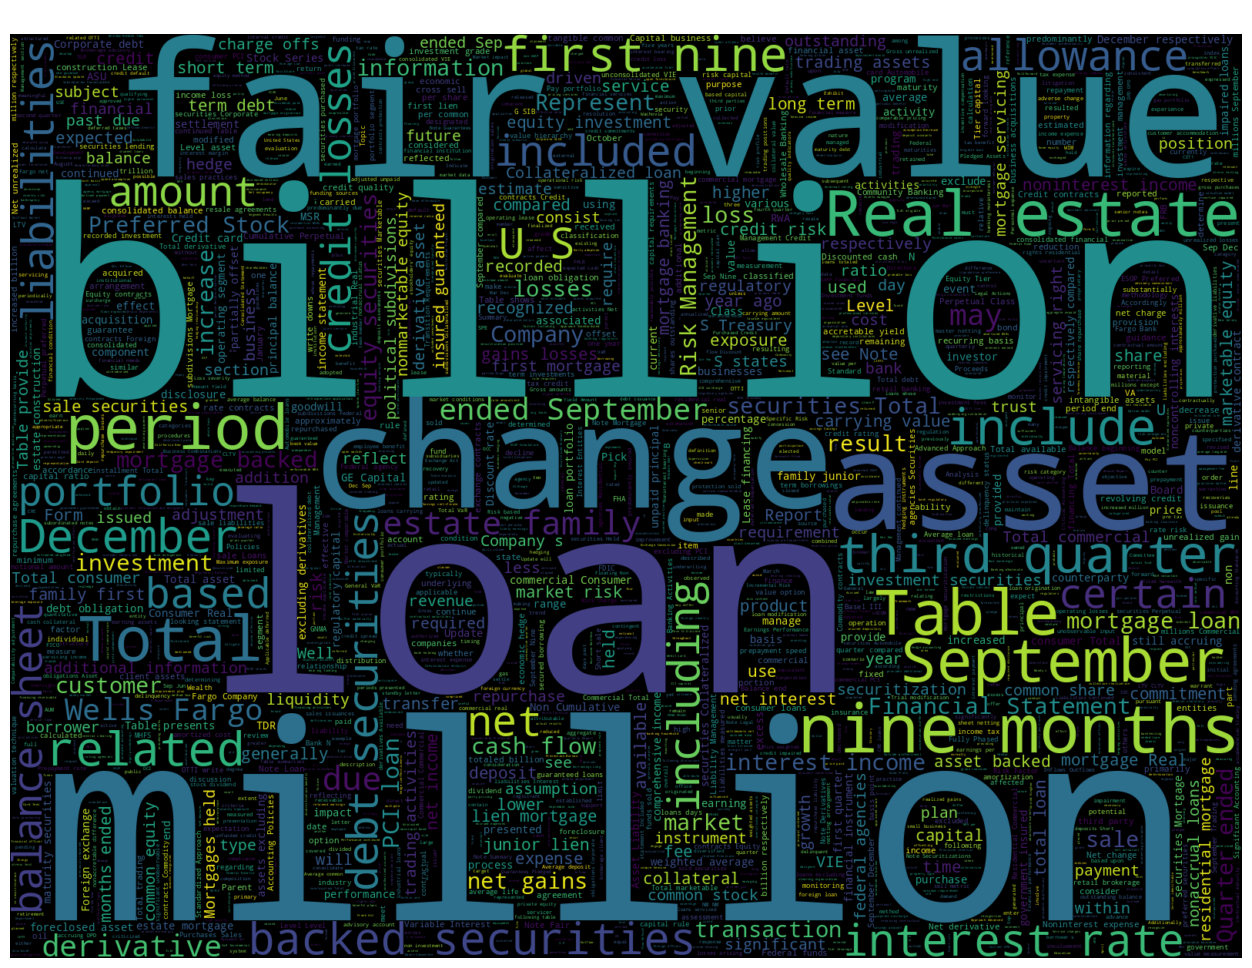

In [125]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

with open('Finance10k.txt') as f:
    text = f.read()

stopwords = set(STOPWORDS)
wc = WordCloud(background_color="black", max_words=2000, stopwords=stopwords,
               width=1600, height=1200)
wc.generate(text)

plt.figure(figsize=(16, 12))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title('Most Frequent Terms in 10-K Filing', color='white', fontsize=16)
plt.show()
# Output generated when run on Colab

The word cloud is a **complementary view** -- it surfaces the **raw frequency** distribution that LDA's topic-word matrix is derived from. Eyeballing the largest words:

- **third quarter**, **first nine**, **nine months** -- indicates this is a **Q3 10-Q filing** (not a full annual 10-K, despite the filename).
- **loan**, **real estate**, **mortgage**, **fair value**, **derivatives** -- the dominant business themes, consistent with LDA's topics.
- **balance**, **liabilities**, **assets** -- balance-sheet-heavy reporting.

**Word cloud vs LDA -- complementary, not redundant.**

| Tool | Strength | Weakness |
|---|---|---|
| Word cloud | Quick visual overview, no parameters | No notion of co-occurrence or topics |
| LDA | Probabilistic topics, multi-document scaling | Requires choosing $K$, slow, can blend |

For a **first-look exploration**, run the word cloud first. For **automated multi-document analysis**, LDA is essential.

**Production extension -- topic time series.** Running LDA across **a sequence of quarterly filings** for the same firm reveals how the firm's reporting emphasis shifts. A spike in topic-1 ("balance sheet & credit") in 2007-2008 filings, for example, would have been an early signal of credit-cycle exposure. This is exactly the kind of **automated regulatory monitoring** that supervisors (Fed, SEC) now run on filings at scale.

---

# Chapter Summary

We covered the full NLP pipeline -- preprocessing, feature representation, and inference -- and applied it to three finance use cases.

**Part 1 -- Theory.** The pipeline:

$$\text{Text} \to \text{Tokens} \to \text{Vectors} \to \text{Predictions}$$

We saw how NLTK, TextBlob, and spaCy each handle these steps with different speed/accuracy tradeoffs, and surveyed bag-of-words, TF-IDF, and word-embedding representations. The inference layer was illustrated with Naive Bayes (supervised) and LDA (unsupervised).

**Case Study 1 -- Sentiment Trading.** We built three sentiment scorers on the same data:

| Scorer | Corr with returns | Best for |
|---|---|---|
| TextBlob | $0.0427$ | Quick baseline |
| LSTM (binary) | $\sim 0.10$ | When labeled data exists |
| VADER + StockTwits lexicon | $\mathbf{0.1183}$ | Production trading |

The lexicon-based strategy was profitable across **all 10 tickers** and across two non-overlapping time windows -- a strong robustness signal.

**Case Study 2 -- Chatbot.** We trained a **custom NER** on 100 synthetic examples in spaCy, plugged it into ChatterBot via a logic adapter, and built a retrieval bot that maps financial-ratio queries to Zacks URLs in milliseconds with zero hallucinations.

**Case Study 3 -- Document Summarization.** LDA on a single 10-K filing surfaced **5 coherent themes** (balance sheet, quarterly metrics, lending, investments, income statement) with no labels, no supervision.

**Strategic takeaways for practitioners.**

1. **Domain matters more than model complexity.** A simple lexicon beat an LSTM in finance because it had the right vocabulary.
2. **Start with classical baselines.** Naive Bayes + TF-IDF gets you 80% of the way for most text classification.
3. **NER is the workhorse.** From sentiment-to-ticker mapping to chatbot slot filling to document tagging -- entity recognition appears in nearly every pipeline.
4. **Sparsity is your friend.** Real text matrices are $>99\%$ sparse; embrace `csr_matrix` and never densify unless you have to.
5. **Topic models are exploratory.** LDA produces hypotheses about a corpus; humans must still interpret and validate the topics.

The frontier has moved on to **transformer-based models** (BERT, FinBERT, GPT-class LLMs), but every concept in this chapter remains relevant -- transformers replace the *representation* step, not the *pipeline* around it.

---

*End of Chapter 10.*